# Reinforcement Learning Individual Assignment
# Monte Carlo Control and Sarsa($\lambda$) for Text Flappy Bird
> Jean-Vincent Martini

In [16]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from IPython.display import clear_output
import time
from tqdm import tqdm

import text_flappy_bird_gym

plt.rcParams.update({"figure.figsize": (10, 5), "font.size": 13})

## 1. Choose environment and demo with a random agent

In [17]:
# Quick demo of the environment
ENV_NAME = "TextFlappyBird-v0"
env = gym.make(ENV_NAME, height=15, width=20, pipe_gap=4)
obs, info = env.reset()

for step in range(200):
    action = env.action_space.sample()
    obs, reward, done, _, info = env.step(action)
    clear_output(wait=True)
    print(env.render())
    time.sleep(0.05)
    if done:
        break

print("Observation:", obs, "Reward:", reward, "Done:", done, "Info:", info)
env.close()

Text Flappy Bird!
Score: 0
----------------------
[      |         |   ]
[      |         |   ]
[      |         |   ]
[      |             ]
[     *|             ]
[      |             ]
[      |             ]
[      |         |   ]
[      |         |   ]
[      |         |   ]
[                |   ]
[                |   ]
[                |   ]
[                |   ]
[      |         |   ]
^^^^^^^^^^^^^^^^^^^^^^
Player Action (Idle)
Distance From Pipe (dx=0,dy=-8)

Observation: (0, -8) Reward: 1 Done: True Info: {'score': 0, 'player': [6, 4], 'distance': np.float64(8.0)}


## 2. Utilitary Functions

In [18]:
def epsilon_greedy_action(Q, state, epsilon, n_actions):
    """Choose an action using epsilon-greedy policy."""
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    q_vals = Q[state]
    return np.random.choice(np.flatnonzero(q_vals == q_vals.max()))


def evaluate_policy(Q, env_name="TextFlappyBird-v0", n_episodes=100, max_steps=50000):
    """Evaluate a greedy policy derived from Q. Returns lists of total rewards and scores."""
    env = gym.make(env_name, height=15, width=20, pipe_gap=4)
    rewards_list, scores_list = [], []
    for _ in tqdm(range(n_episodes), desc="Evaluating policy"):
        obs, info = env.reset()
        total_reward = 0
        for _ in range(max_steps):
            q_vals = Q.get(obs, np.zeros(env.action_space.n))
            action = np.random.choice(np.flatnonzero(q_vals == q_vals.max()))
            obs, reward, done, _, info = env.step(action)
            total_reward += reward
            if done:
                break
        rewards_list.append(total_reward)
        scores_list.append(info["score"])
    env.close()
    return rewards_list, scores_list


def hashable_obs(obs):
    """Convert a numpy array observation to a hashable tuple for using as dict keys."""
    return tuple(map(tuple, obs))


def evaluate_policy_screen(
    Q, env_name="TextFlappyBird-screen-v0", n_episodes=100, max_steps=50000
):
    """Evaluate a greedy policy for screen-based env."""
    env = gym.make(env_name, height=15, width=20, pipe_gap=4)
    rewards_list, scores_list = [], []
    for _ in tqdm(range(n_episodes), desc="Evaluating policy"):
        obs, info = env.reset()
        state = hashable_obs(obs)
        total_reward = 0
        for _ in range(max_steps):
            q_vals = Q.get(state, np.zeros(env.action_space.n))
            action = np.random.choice(np.flatnonzero(q_vals == q_vals.max()))
            obs, reward, done, _, info = env.step(action)
            state = hashable_obs(obs)
            total_reward += reward
            if done:
                break
        rewards_list.append(total_reward)
        scores_list.append(info["score"])
    env.close()
    return rewards_list, scores_list


def plot_training_curves(stats, title=""):
    """Plot episode rewards and scores over training."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    window = min(200, len(stats["rewards"]) // 5 or 1)

    rewards = np.array(stats["rewards"], dtype=float)
    scores = np.array(stats["scores"], dtype=float)

    if len(rewards) >= window:
        kernel = np.ones(window) / window
        avg_rewards = np.convolve(rewards, kernel, mode="valid")
        avg_scores = np.convolve(scores, kernel, mode="valid")
    else:
        avg_rewards, avg_scores = rewards, scores

    axes[0].plot(avg_rewards)
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Total Reward (running avg)")
    axes[0].set_title(f"{title} - Rewards")

    axes[1].plot(avg_scores, color="tab:orange")
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Score (running avg)")
    axes[1].set_title(f"{title} - Scores")

    plt.tight_layout()
    plt.show()


def plot_q_simple(Q, title=""):
    """Plot V(s) = max_a Q(s,a) and greedy policy for simple (x_dist, y_dist) obs."""
    states = [s for s in Q if isinstance(s, tuple) and len(s) == 2]
    if not states:
        print("No states to plot.")
        return
    x = np.array([s[0] for s in states])
    y = np.array([s[1] for s in states])
    v = np.array([Q[s].max() for s in states])
    actions = np.array([Q[s].argmax() for s in states])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # V(s)
    sc = axes[0].scatter(x, y, c=v, cmap="viridis", s=50, edgecolors="none")
    axes[0].set_xlabel("x_dist (horizontal to pipe)")
    axes[0].set_ylabel("y_dist (vertical to gap center)")
    axes[0].set_title(f"{title} – State-Value")
    fig.colorbar(sc, ax=axes[0], label="V(s)")

    # Policy
    sc2 = axes[1].scatter(
        x, y, c=actions, cmap="coolwarm", s=50, edgecolors="none", vmin=0, vmax=1
    )
    axes[1].set_xlabel("x_dist")
    axes[1].set_ylabel("y_dist")
    axes[1].set_title(f"{title} – Policy")
    cbar = fig.colorbar(sc2, ax=axes[1], ticks=[0, 1])
    cbar.ax.set_yticklabels(["Idle", "Flap"])

    plt.tight_layout()
    plt.show()


def plot_q_screen(Q, title=""):
    """Plot V(s) distribution and policy breakdown for screen-based Q-table."""
    if not Q:
        print("No states to plot.")
        return
    v_vals = np.array([Q[s].max() for s in Q])
    actions = np.array([Q[s].argmax() for s in Q])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram of V(s)
    axes[0].hist(v_vals, bins=50, edgecolor="black", alpha=0.8)
    axes[0].set_xlabel("V(s) = max_a Q(s,a)")
    axes[0].set_ylabel("Number of states")
    axes[0].set_title(f"{title} – State-Value Distribution")

    # Policy breakdown
    n_idle = np.sum(actions == 0)
    n_flap = np.sum(actions == 1)
    bars = axes[1].bar(
        ["Idle (0)", "Flap (1)"],
        [n_idle, n_flap],
        color=["tab:blue", "tab:red"],
        edgecolor="black",
    )
    axes[1].set_ylabel("Number of states")
    axes[1].set_title(f"{title} – Policy Breakdown")
    for bar, val in zip(bars, [n_idle, n_flap]):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(val),
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    plt.tight_layout()
    plt.show()

### Tile Coding for Screen Observations

Instead of hashing the raw screen array (which yields an enormous, non-generalizing state space), we **extract features** $(d_x, d_y)$ from the screen and apply **tile coding** with linear function approximation for generalization.

In [19]:
class TileCoding:
    """Tile coding for continuous features with multiple overlapping tilings."""

    def __init__(
        self, num_tilings=8, tiles_per_dim=4, feature_ranges=((0, 14), (-12, 12))
    ):
        self.num_tilings = num_tilings
        self.tiles_per_dim = tiles_per_dim
        self.feature_ranges = feature_ranges
        self.num_dims = len(feature_ranges)
        # Uniform offsets across tilings
        self.offsets = [
            tuple(i / num_tilings for _ in range(self.num_dims))
            for i in range(num_tilings)
        ]

    def get_tiles(self, features):
        """Return a tuple of active tile indices (one per tiling)."""
        tiles = []
        for tiling_idx in range(self.num_tilings):
            idx = [tiling_idx]
            for d in range(self.num_dims):
                f_min, f_max = self.feature_ranges[d]
                f_range = f_max - f_min if f_max != f_min else 1
                scaled = (features[d] - f_min) / f_range * self.tiles_per_dim
                scaled += self.offsets[tiling_idx][d]
                tile = int(np.floor(scaled))
                tile = max(0, min(tile, self.tiles_per_dim))
                idx.append(tile)
            tiles.append(tuple(idx))
        return tuple(tiles)


def extract_features_from_screen(obs):
    """Extract (dx, dy) from screen observation (shape: width x height).

    dx = horizontal distance to nearest upcoming pipe
    dy = vertical offset of player from gap center
    """
    player_pos = np.argwhere(obs == 1)
    if len(player_pos) == 0:
        player_pos = np.argwhere(obs == 3)
    if len(player_pos) == 0:
        return (0, 0)
    player_x, player_y = player_pos[0]

    pipe_positions = np.argwhere(obs == 2)
    if len(pipe_positions) == 0:
        return (0, 0)

    pipe_xs = np.unique(pipe_positions[:, 0])
    upcoming = pipe_xs[pipe_xs >= player_x]
    if len(upcoming) == 0:
        return (0, 0)

    nearest_x = upcoming[0]
    dx = nearest_x - player_x

    pipe_ys = set(pipe_positions[pipe_positions[:, 0] == nearest_x, 1])
    gap_ys = sorted(set(range(obs.shape[1])) - pipe_ys)
    gap_center = (gap_ys[0] + gap_ys[-1]) / 2.0 if gap_ys else obs.shape[1] / 2.0
    dy = player_y - gap_center

    return (dx, dy)


def tile_get_q(w, tile_coder, features, n_actions=2):
    """Compute Q-values from tile-coded weights."""
    q = np.zeros(n_actions)
    for t in tile_coder.get_tiles(features):
        q += w[t]
    return q


def evaluate_policy_screen_tile(
    w,
    tile_coder,
    env_name="TextFlappyBird-screen-v0",
    n_episodes=100,
    max_steps=50000,
    **env_kwargs,
):
    """Evaluate a greedy policy derived from tile-coded weights."""
    if not env_kwargs:
        env_kwargs = {"height": 15, "width": 20, "pipe_gap": 4}
    env = gym.make(env_name, **env_kwargs)
    n_actions = env.action_space.n
    rewards_list, scores_list = [], []
    for _ in tqdm(range(n_episodes), desc="Evaluating policy"):
        obs, info = env.reset()
        features = extract_features_from_screen(obs)
        total_reward = 0
        for _ in range(max_steps):
            q = tile_get_q(w, tile_coder, features, n_actions)
            action = np.random.choice(np.flatnonzero(q == q.max()))
            obs, reward, done, _, info = env.step(action)
            features = extract_features_from_screen(obs)
            total_reward += reward
            if done:
                break
        rewards_list.append(total_reward)
        scores_list.append(info["score"])
    env.close()
    return rewards_list, scores_list


def plot_q_tile(w, tile_coder, title="", dx_range=(0, 14), dy_range=(-12, 12)):
    """Plot V(s) and greedy policy on a (dx, dy) grid for tile-coded Q."""
    dx_vals = np.arange(dx_range[0], dx_range[1] + 1)
    dy_vals = np.arange(dy_range[0], dy_range[1] + 1)
    V = np.zeros((len(dx_vals), len(dy_vals)))
    pol = np.zeros_like(V)
    for i, dx in enumerate(dx_vals):
        for j, dy in enumerate(dy_vals):
            q = tile_get_q(w, tile_coder, (dx, dy))
            V[i, j] = q.max()
            pol[i, j] = q.argmax()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    xs = np.repeat(dx_vals, len(dy_vals))
    ys = np.tile(dy_vals, len(dx_vals))

    sc = axes[0].scatter(xs, ys, c=V.flatten(), cmap="viridis", s=50, edgecolors="none")
    axes[0].set_xlabel("dx")
    axes[0].set_ylabel("dy")
    axes[0].set_title(f"{title} – State-Value")
    fig.colorbar(sc, ax=axes[0], label="V(s)")

    sc2 = axes[1].scatter(
        xs,
        ys,
        c=pol.flatten(),
        cmap="coolwarm",
        s=50,
        edgecolors="none",
        vmin=0,
        vmax=1,
    )
    axes[1].set_xlabel("dx")
    axes[1].set_ylabel("dy")
    axes[1].set_title(f"{title} – Policy")
    cbar = fig.colorbar(sc2, ax=axes[1], ticks=[0, 1])
    cbar.ax.set_yticklabels(["Idle", "Flap"])

    plt.tight_layout()
    plt.show()

## 3. Monte Carlo Control (constant-$\alpha$, $\epsilon$-greedy)

We implement an **MC control** agent with constant step-size $\alpha$ and $\epsilon$-greedy exploration. At the end of each episode, every visited state-action pair is updated using the discounted return from that point onward:

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ G_t - Q(S_t, A_t) \right]$$

where $G_t = \sum_{k=0}^{T-t-1} \gamma^k R_{t+k+1}$ is the return from time $t$.

The parameter $\epsilon$ is decayed geometrically: $\epsilon_{i+1} = \max(\epsilon_i \cdot \texttt{eps\_decay},\; \epsilon_{\min})$.

In [20]:
def mc_control(
    env,
    num_episodes=10000,
    alpha=0.01,
    gamma=0.99,
    eps_start=1.0,
    eps_decay=0.9999,
    eps_min=0.01,
):
    """
    Constant-alpha MC Control with epsilon-greedy exploration.
    Returns Q (defaultdict) and training stats.
    """
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions))
    epsilon = eps_start
    stats = {"rewards": [], "scores": []}

    for ep in tqdm(range(num_episodes), desc="MCC"):
        # Generate episode
        episode = []
        obs, info = env.reset()
        done = False
        while not done:
            action = epsilon_greedy_action(Q, obs, epsilon, n_actions)
            next_obs, reward, done, _, info = env.step(action)
            episode.append((obs, action, reward))
            obs = next_obs

        # Update Q from episode (every-visit)
        G = 0.0
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = gamma * G + reward
            Q[state][action] += alpha * (G - Q[state][action])

        stats["rewards"].append(sum(r for _, _, r in episode))
        stats["scores"].append(info["score"])

        # Decay epsilon
        epsilon = max(epsilon * eps_decay, eps_min)

    return Q, stats

### 3.1 MC Control on `TextFlappyBird-v0` (Simple observations)

MCC: 100%|██████████| 25000/25000 [00:50<00:00, 496.60it/s] 


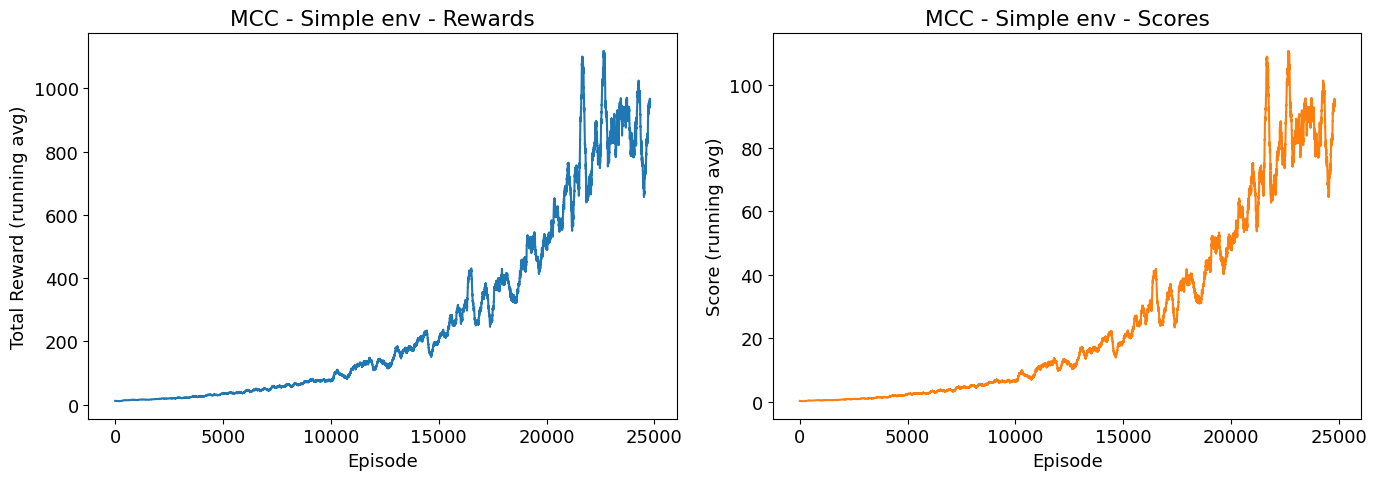

In [21]:
env_mc = gym.make("TextFlappyBird-v0", height=15, width=20, pipe_gap=4)

Q_mc, stats_mc = mc_control(
    env_mc,
    num_episodes=25000,
    alpha=0.01,
    gamma=0.99,
    eps_start=1.0,
    eps_decay=0.9998,
    eps_min=0.01,
)
env_mc.close()

plot_training_curves(stats_mc, title="MCC - Simple env")

In [22]:
# Evaluate trained MC agent
rewards_eval, scores_eval = evaluate_policy(Q_mc, "TextFlappyBird-v0", n_episodes=200)

print("MCC - Simple env  |  Evaluation over 200 episodes")
print(f"Mean reward: {np.mean(rewards_eval):.1f} +/- {np.std(rewards_eval):.1f}")
print(f"Mean score: {np.mean(scores_eval):.2f} +/- {np.std(scores_eval):.2f}")
print(f"Median reward: {np.median(rewards_eval):.1f}")
print(f"Median score: {np.median(scores_eval):.2f}")
print(f"Q-table size: {len(Q_mc)} states")

Evaluating policy: 100%|██████████| 200/200 [01:12<00:00,  2.74it/s]

MCC - Simple env  |  Evaluation over 200 episodes
Mean reward: 50000.0 +/- 0.0
Mean score: 4999.00 +/- 0.00
Median reward: 50000.0
Median score: 4999.00
Q-table size: 273 states


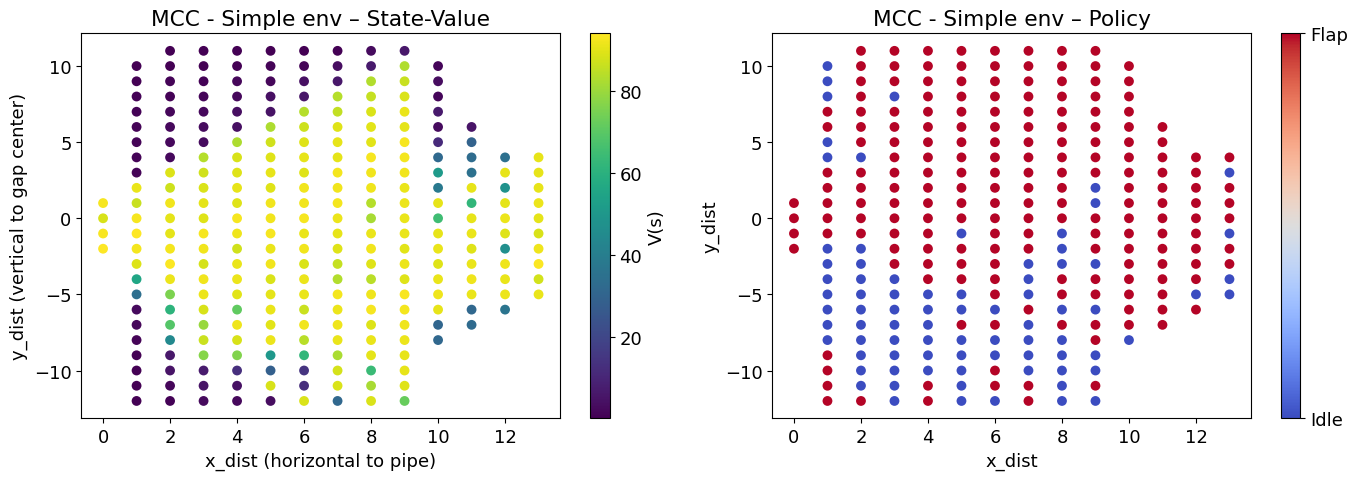

In [23]:
plot_q_simple(Q_mc, title="MCC - Simple env")

### 3.2 MC Control on `TextFlappyBird-screen-v0` (Screen observations)

The screen environment returns a 2-D numpy array; we convert it to a hashable tuple so it can be used as a dictionary key.

In [24]:
def mc_control_screen(
    env,
    num_episodes=10000,
    alpha=0.01,
    gamma=0.99,
    eps_start=1.0,
    eps_decay=0.9999,
    eps_min=0.01,
):
    """MC Control adapted for screen-based (array) observations."""
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions))
    epsilon = eps_start
    stats = {"rewards": [], "scores": []}

    for ep in tqdm(range(num_episodes), desc="MCC Screen"):
        episode = []
        obs, info = env.reset()
        state = hashable_obs(obs)
        done = False
        while not done:
            action = epsilon_greedy_action(Q, state, epsilon, n_actions)
            next_obs, reward, done, _, info = env.step(action)
            episode.append((state, action, reward))
            state = hashable_obs(next_obs)

        G = 0.0
        for t in reversed(range(len(episode))):
            s, a, r = episode[t]
            G = gamma * G + r
            Q[s][a] += alpha * (G - Q[s][a])

        stats["rewards"].append(sum(r for _, _, r in episode))
        stats["scores"].append(info["score"])
        epsilon = max(epsilon * eps_decay, eps_min)

    return Q, stats

MCC Screen: 100%|██████████| 25000/25000 [01:36<00:00, 259.80it/s]


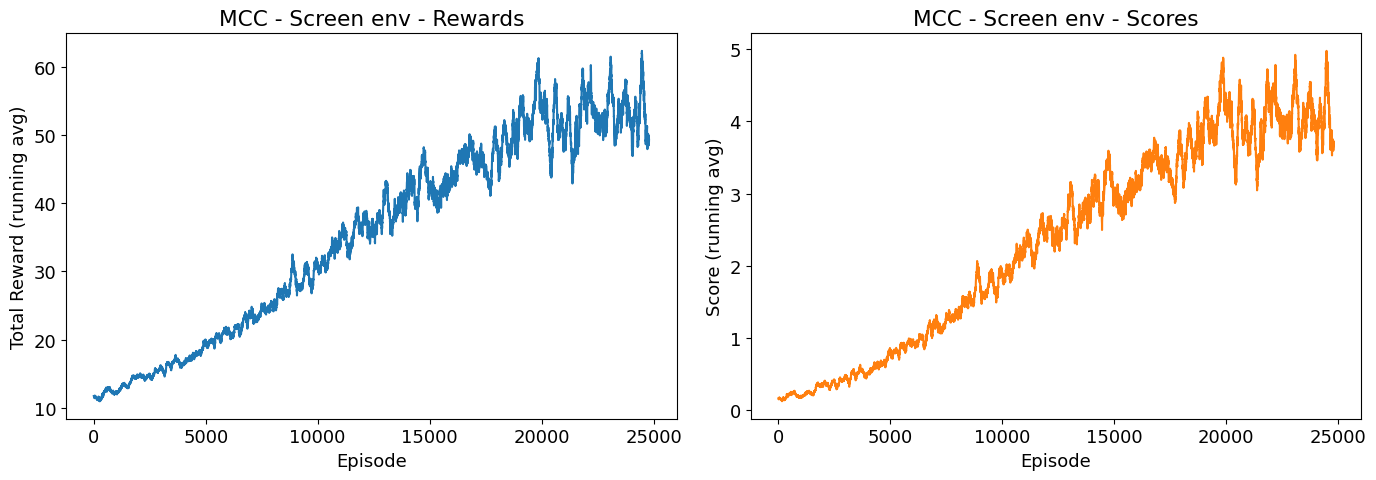

In [25]:
env_mc_scr = gym.make("TextFlappyBird-screen-v0", height=15, width=20, pipe_gap=4)

Q_mc_scr, stats_mc_scr = mc_control_screen(
    env_mc_scr,
    num_episodes=25000,
    alpha=0.01,
    gamma=0.99,
    eps_start=1.0,
    eps_decay=0.9998,
    eps_min=0.01,
)
env_mc_scr.close()

plot_training_curves(stats_mc_scr, title="MCC - Screen env")

In [26]:
# Evaluate trained MC agent on screen env
rewards_eval_scr, scores_eval_scr = evaluate_policy_screen(
    Q_mc_scr, "TextFlappyBird-screen-v0", n_episodes=200
)

print("MCC - Screen env  |  Evaluation over 200 episodes")
print(
    f"Mean reward: {np.mean(rewards_eval_scr):.1f} +/- {np.std(rewards_eval_scr):.1f}"
)
print(f"Mean score: {np.mean(scores_eval_scr):.2f} +/- {np.std(scores_eval_scr):.2f}")
print(f"Median reward: {np.median(rewards_eval_scr):.1f}")
print(f"Median score: {np.median(scores_eval_scr):.2f}")
print(f"Q-table size: {len(Q_mc_scr)} states")

Evaluating policy: 100%|██████████| 200/200 [00:01<00:00, 157.36it/s]

MCC - Screen env  |  Evaluation over 200 episodes
Mean reward: 58.6 +/- 52.2
Mean score: 4.59 +/- 5.21
Median reward: 41.5
Median score: 3.00
Q-table size: 9466 states


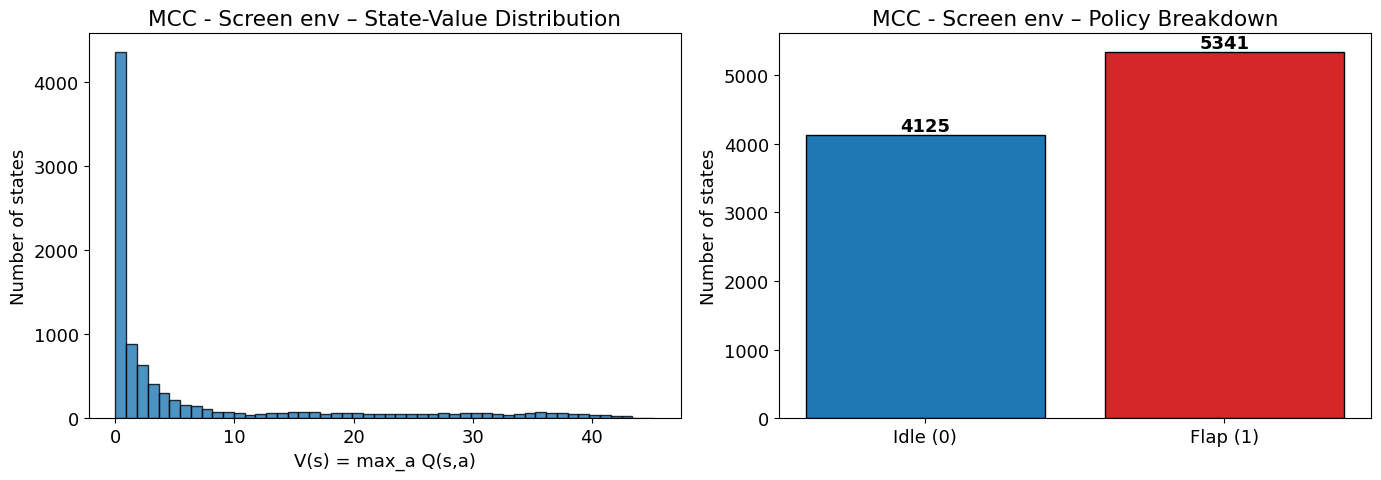

In [27]:
plot_q_screen(Q_mc_scr, title="MCC - Screen env")

### 3.3 MC Control on `TextFlappyBird-screen-v0` with Tile Coding

In [28]:
def mc_control_screen_tile(
    env,
    tile_coder,
    num_episodes=10000,
    alpha=0.01,
    gamma=0.99,
    eps_start=1.0,
    eps_decay=0.9999,
    eps_min=0.01,
):
    """MC Control with tile coding for screen-based observations."""
    n_actions = env.action_space.n
    w = defaultdict(lambda: np.zeros(n_actions))
    epsilon = eps_start
    stats = {"rewards": [], "scores": []}
    step_size = alpha / tile_coder.num_tilings

    for ep in tqdm(range(num_episodes), desc="MCC Tile"):
        episode = []
        obs, info = env.reset()
        features = extract_features_from_screen(obs)
        done = False
        while not done:
            q_vals = tile_get_q(w, tile_coder, features, n_actions)
            if np.random.rand() < epsilon:
                action = np.random.randint(n_actions)
            else:
                action = np.random.choice(np.flatnonzero(q_vals == q_vals.max()))
            next_obs, reward, done, _, info = env.step(action)
            episode.append((features, action, reward))
            features = extract_features_from_screen(next_obs)

        G = 0.0
        for t in reversed(range(len(episode))):
            feat, action, reward = episode[t]
            G = gamma * G + reward
            delta = G - tile_get_q(w, tile_coder, feat, n_actions)[action]
            for tile in tile_coder.get_tiles(feat):
                w[tile][action] += step_size * delta

        stats["rewards"].append(sum(r for _, _, r in episode))
        stats["scores"].append(info["score"])
        epsilon = max(epsilon * eps_decay, eps_min)

    return w, stats

MCC Tile: 100%|██████████| 25000/25000 [11:58<00:00, 34.81it/s] 


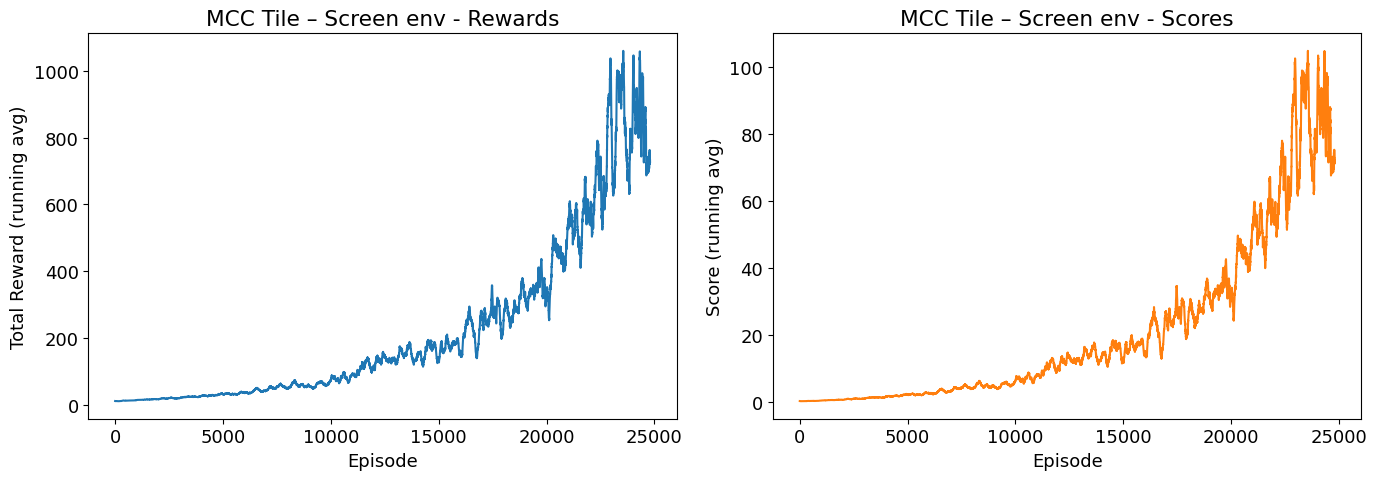

In [29]:
tile_coder_mc = TileCoding(
    num_tilings=8, tiles_per_dim=4, feature_ranges=((0, 14), (-12, 12))
)

env_mc_tile = gym.make("TextFlappyBird-screen-v0", height=15, width=20, pipe_gap=4)
w_mc_tile, stats_mc_tile = mc_control_screen_tile(
    env_mc_tile,
    tile_coder_mc,
    num_episodes=25000,
    alpha=0.01,
    gamma=0.99,
    eps_start=1.0,
    eps_decay=0.9998,
    eps_min=0.01,
)
env_mc_tile.close()

plot_training_curves(stats_mc_tile, title="MCC Tile – Screen env")

In [30]:
# Evaluate trained MC Tile agent
rewards_eval_mc_tile, scores_eval_mc_tile = evaluate_policy_screen_tile(
    w_mc_tile, tile_coder_mc, "TextFlappyBird-screen-v0", n_episodes=100
)

print("MCC Tile – Screen env  |  Evaluation over 100 episodes")
print(
    f"Mean reward: {np.mean(rewards_eval_mc_tile):.1f} +/- {np.std(rewards_eval_mc_tile):.1f}"
)
print(
    f"Mean score: {np.mean(scores_eval_mc_tile):.2f} +/- {np.std(scores_eval_mc_tile):.2f}"
)
print(f"Median reward: {np.median(rewards_eval_mc_tile):.1f}")
print(f"Median score: {np.median(scores_eval_mc_tile):.2f}")
print(f"Weight table size: {len(w_mc_tile)} tiles")

Evaluating policy:   0%|          | 0/100 [00:00<?, ?it/s]

Evaluating policy: 100%|██████████| 100/100 [08:45<00:00,  5.26s/it]

MCC Tile – Screen env  |  Evaluation over 100 episodes
Mean reward: 50000.0 +/- 0.0
Mean score: 4999.00 +/- 0.00
Median reward: 50000.0
Median score: 4999.00
Weight table size: 161 tiles


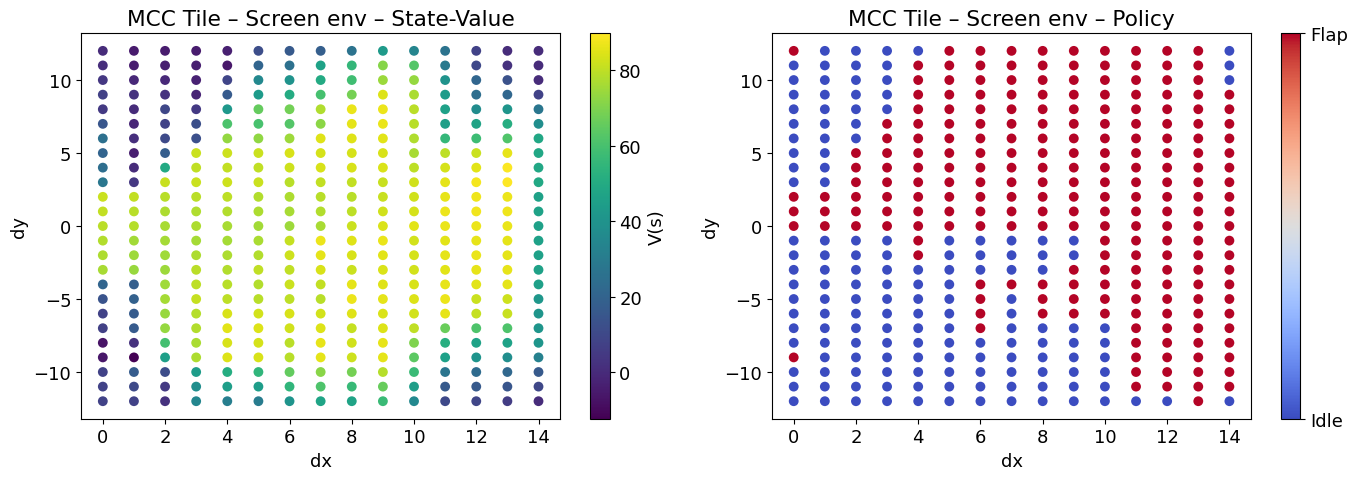

In [31]:
plot_q_tile(w_mc_tile, tile_coder_mc, title="MCC Tile – Screen env")

## 4. Sarsa($\lambda$) with Eligibility Traces

Sarsa($\lambda$) is an online, on-policy TD method that uses **eligibility traces** to bridge the gap between one-step Sarsa ($\lambda=0$) and Monte Carlo ($\lambda=1$). At every step the agent updates all previously visited state-action pairs proportionally to their eligibility:

$$\delta_t = R_{t+1} + \gamma\, Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)$$
$$e_t(s,a) = \gamma \lambda\, e_{t-1}(s,a) + \mathbf{1}[S_t=s, A_t=a]$$
$$Q(s,a) \leftarrow Q(s,a) + \alpha\, \delta_t\, e_t(s,a)$$

In [5]:
def sarsa_lambda(
    env,
    num_episodes=10000,
    alpha=0.01,
    gamma=0.99,
    lam=0.8,
    eps_start=1.0,
    eps_decay=0.9999,
    eps_min=0.01,
):
    """
    Sarsa(lambda) with replacing eligibility traces and epsilon-greedy exploration.
    Works with hashable (tuple) observations.
    """
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions))
    epsilon = eps_start
    stats = {"rewards": [], "scores": []}

    for ep in tqdm(range(num_episodes), desc="Sarsa"):
        E = defaultdict(lambda: np.zeros(n_actions))  # eligibility traces
        obs, info = env.reset()
        action = epsilon_greedy_action(Q, obs, epsilon, n_actions)
        total_reward = 0
        done = False

        while not done:
            next_obs, reward, done, _, info = env.step(action)
            total_reward += reward

            if done:
                delta = reward - Q[obs][action]
                E[obs][action] += 1  # accumulating trace
                for s in list(E.keys()):
                    Q[s] += alpha * delta * E[s]
                    E[s] *= gamma * lam
                    if np.max(np.abs(E[s])) < 1e-10:
                        del E[s]
                break

            next_action = epsilon_greedy_action(Q, next_obs, epsilon, n_actions)
            delta = reward + gamma * Q[next_obs][next_action] - Q[obs][action]

            E[obs][action] += 1  # accumulating trace

            # Update all visited state-action pairs
            for s in list(E.keys()):
                Q[s] += alpha * delta * E[s]
                E[s] *= gamma * lam
                if np.max(np.abs(E[s])) < 1e-10:
                    del E[s]

            obs = next_obs
            action = next_action

        stats["rewards"].append(total_reward)
        stats["scores"].append(info["score"])
        epsilon = max(epsilon * eps_decay, eps_min)

    return Q, stats

### 4.1 Sarsa($\lambda$) on `TextFlappyBird-v0` (Simple observations)

Sarsa: 100%|██████████| 25000/25000 [11:52<00:00, 35.08it/s] 


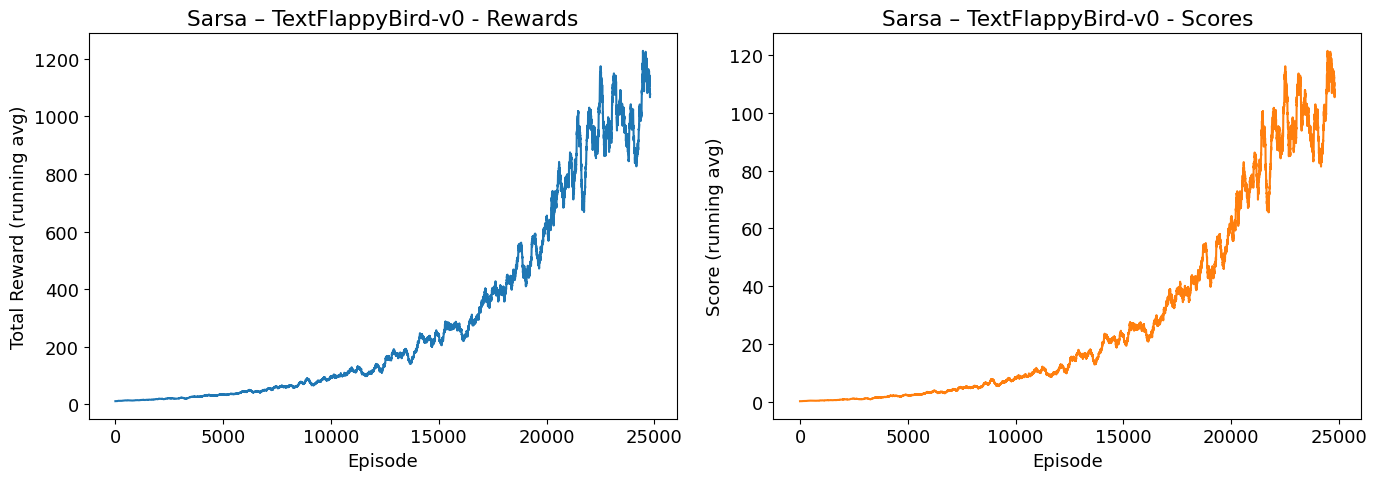

In [6]:
env_sarsa = gym.make("TextFlappyBird-v0", height=15, width=20, pipe_gap=4)

Q_sarsa, stats_sarsa = sarsa_lambda(
    env_sarsa,
    num_episodes=25000,
    alpha=0.05,
    gamma=0.99,
    lam=0.8,
    eps_start=1.0,
    eps_decay=0.9998,
    eps_min=0.01,
)
env_sarsa.close()

plot_training_curves(stats_sarsa, title="Sarsa – TextFlappyBird-v0")

In [7]:
# Evaluate trained Sarsa agent
rewards_eval_s, scores_eval_s = evaluate_policy(
    Q_sarsa, "TextFlappyBird-v0", n_episodes=200
)

print("Sarsa – TextFlappyBird-v0  |  Evaluation over 200 episodes")
print(f"Mean reward: {np.mean(rewards_eval_s):.1f} +/- {np.std(rewards_eval_s):.1f}")
print(f"Mean score: {np.mean(scores_eval_s):.2f} +/- {np.std(scores_eval_s):.2f}")
print(f"Median reward: {np.median(rewards_eval_s):.1f}")
print(f"Median score: {np.median(scores_eval_s):.2f}")
print(f"Q-table size: {len(Q_sarsa)} states")

Evaluating policy: 100%|██████████| 200/200 [01:13<00:00,  2.74it/s]

Sarsa – TextFlappyBird-v0  |  Evaluation over 200 episodes
Mean reward: 50000.0 +/- 0.0
Mean score: 4999.00 +/- 0.00
Median reward: 50000.0
Median score: 4999.00
Q-table size: 273 states


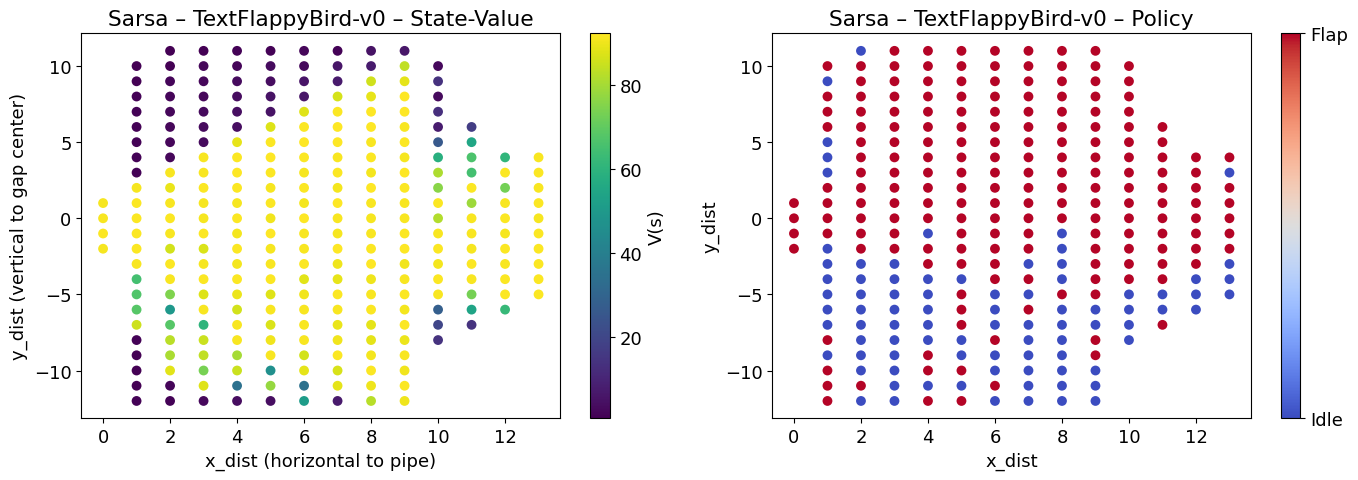

In [32]:
plot_q_simple(Q_sarsa, title="Sarsa – TextFlappyBird-v0")

### 4.2 Sarsa($\lambda$) on `TextFlappyBird-screen-v0` (Screen observations)

In [33]:
def sarsa_lambda_screen(
    env,
    num_episodes=10000,
    alpha=0.01,
    gamma=0.99,
    lam=0.8,
    eps_start=1.0,
    eps_decay=0.9999,
    eps_min=0.01,
):
    """Sarsa(lambda) adapted for screen-based (array) observations."""
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions))
    epsilon = eps_start
    stats = {"rewards": [], "scores": []}

    for ep in tqdm(range(num_episodes), desc="Sarsa Screen"):
        E = defaultdict(lambda: np.zeros(n_actions))
        obs_raw, info = env.reset()
        obs = hashable_obs(obs_raw)
        action = epsilon_greedy_action(Q, obs, epsilon, n_actions)
        total_reward = 0
        done = False

        while not done:
            next_obs_raw, reward, done, _, info = env.step(action)
            total_reward += reward
            next_obs = hashable_obs(next_obs_raw)

            if done:
                delta = reward - Q[obs][action]
                E[obs][action] += 1
                for s in list(E.keys()):
                    Q[s] += alpha * delta * E[s]
                    E[s] *= gamma * lam
                    if np.max(np.abs(E[s])) < 1e-10:
                        del E[s]
                break

            next_action = epsilon_greedy_action(Q, next_obs, epsilon, n_actions)
            delta = reward + gamma * Q[next_obs][next_action] - Q[obs][action]
            E[obs][action] += 1

            for s in list(E.keys()):
                Q[s] += alpha * delta * E[s]
                E[s] *= gamma * lam
                if np.max(np.abs(E[s])) < 1e-10:
                    del E[s]

            obs = next_obs
            action = next_action

        stats["rewards"].append(total_reward)
        stats["scores"].append(info["score"])
        epsilon = max(epsilon * eps_decay, eps_min)

    return Q, stats

Sarsa Screen: 100%|██████████| 25000/25000 [01:56<00:00, 214.95it/s]


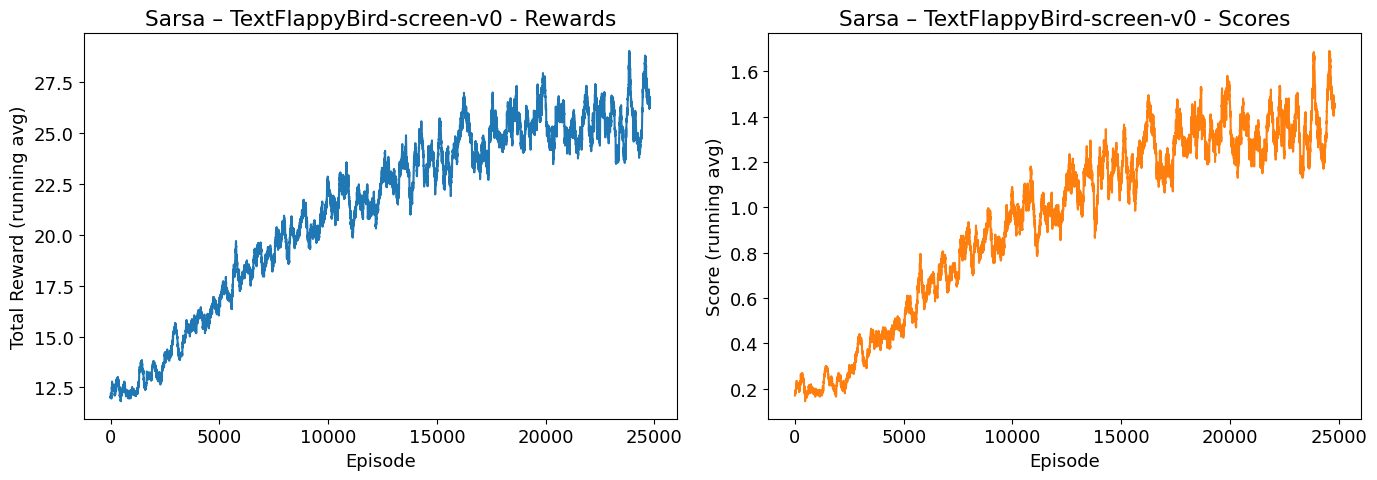

In [34]:
env_sarsa_scr = gym.make("TextFlappyBird-screen-v0", height=15, width=20, pipe_gap=4)

Q_sarsa_scr, stats_sarsa_scr = sarsa_lambda_screen(
    env_sarsa_scr,
    num_episodes=25000,
    alpha=0.01,
    gamma=0.99,
    lam=0.8,
    eps_start=1.0,
    eps_decay=0.9998,
    eps_min=0.01,
)
env_sarsa_scr.close()

plot_training_curves(stats_sarsa_scr, title="Sarsa – TextFlappyBird-screen-v0")

In [35]:
# Evaluate trained Sarsa agent on screen env
rewards_eval_ss, scores_eval_ss = evaluate_policy_screen(
    Q_sarsa_scr, "TextFlappyBird-screen-v0", n_episodes=200
)

print("Sarsa – TextFlappyBird-screen-v0  |  Evaluation over 200 episodes")
print(f"Mean reward: {np.mean(rewards_eval_ss):.1f} +/- {np.std(rewards_eval_ss):.1f}")
print(f"Mean score: {np.mean(scores_eval_ss):.2f} +/- {np.std(scores_eval_ss):.2f}")
print(f"Median reward: {np.median(rewards_eval_ss):.1f}")
print(f"Median score: {np.median(scores_eval_ss):.2f}")
print(f"Q-table size: {len(Q_sarsa_scr)} states")

Evaluating policy: 100%|██████████| 200/200 [00:00<00:00, 339.54it/s]

Sarsa – TextFlappyBird-screen-v0  |  Evaluation over 200 episodes
Mean reward: 25.9 +/- 16.8
Mean score: 1.40 +/- 1.68
Median reward: 23.0
Median score: 1.00
Q-table size: 8916 states


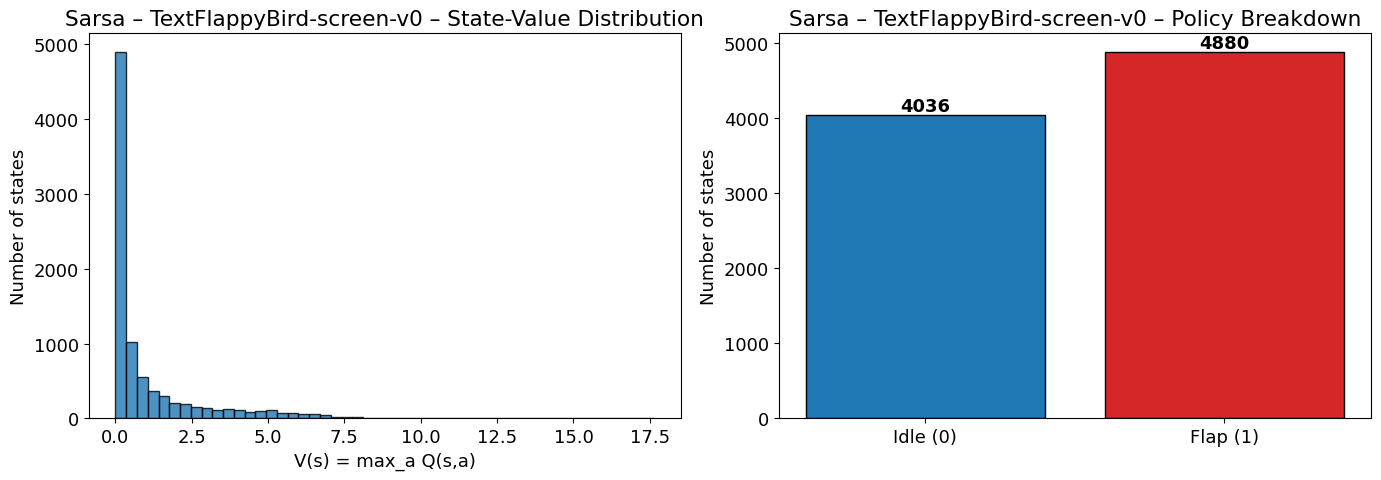

In [36]:
plot_q_screen(Q_sarsa_scr, title="Sarsa – TextFlappyBird-screen-v0")

### 4.3 Sarsa($\lambda$) on `TextFlappyBird-screen-v0` with Tile Coding

In [37]:
def sarsa_lambda_screen_tile(
    env,
    tile_coder,
    num_episodes=10000,
    alpha=0.01,
    gamma=0.99,
    lam=0.8,
    eps_start=1.0,
    eps_decay=0.9999,
    eps_min=0.01,
):
    """Sarsa(lambda) with tile coding for screen-based observations."""
    n_actions = env.action_space.n
    w = defaultdict(lambda: np.zeros(n_actions))
    epsilon = eps_start
    stats = {"rewards": [], "scores": []}
    step_size = alpha / tile_coder.num_tilings

    for ep in tqdm(range(num_episodes), desc="Sarsa Tile"):
        E = defaultdict(lambda: np.zeros(n_actions))  # eligibility traces on tiles
        obs, info = env.reset()
        features = extract_features_from_screen(obs)
        q_vals = tile_get_q(w, tile_coder, features, n_actions)
        action = (
            np.random.randint(n_actions)
            if np.random.rand() < epsilon
            else np.random.choice(np.flatnonzero(q_vals == q_vals.max()))
        )
        total_reward = 0
        done = False

        while not done:
            next_obs, reward, done, _, info = env.step(action)
            total_reward += reward
            next_features = extract_features_from_screen(next_obs)

            if done:
                delta = reward - tile_get_q(w, tile_coder, features, n_actions)[action]
                for tile in tile_coder.get_tiles(features):
                    E[tile][action] += 1
                for tile in list(E.keys()):
                    w[tile] += step_size * delta * E[tile]
                    E[tile] *= gamma * lam
                    if np.max(np.abs(E[tile])) < 1e-10:
                        del E[tile]
                break

            next_q = tile_get_q(w, tile_coder, next_features, n_actions)
            next_action = (
                np.random.randint(n_actions)
                if np.random.rand() < epsilon
                else np.random.choice(np.flatnonzero(next_q == next_q.max()))
            )
            delta = (
                reward
                + gamma * next_q[next_action]
                - tile_get_q(w, tile_coder, features, n_actions)[action]
            )
            for tile in tile_coder.get_tiles(features):
                E[tile][action] += 1
            for tile in list(E.keys()):
                w[tile] += step_size * delta * E[tile]
                E[tile] *= gamma * lam
                if np.max(np.abs(E[tile])) < 1e-10:
                    del E[tile]

            features = next_features
            action = next_action

        stats["rewards"].append(total_reward)
        stats["scores"].append(info["score"])
        epsilon = max(epsilon * eps_decay, eps_min)

    return w, stats

Sarsa Tile: 100%|██████████| 25000/25000 [37:04<00:00, 11.24it/s]


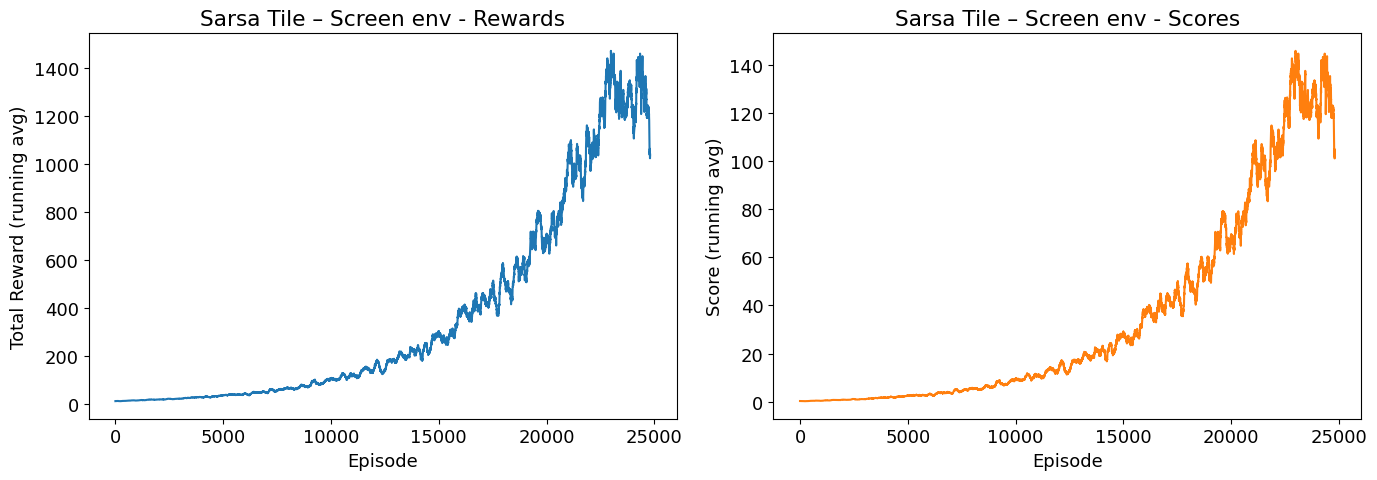

In [38]:
tile_coder_sarsa = TileCoding(
    num_tilings=8, tiles_per_dim=4, feature_ranges=((0, 14), (-12, 12))
)

env_sarsa_tile = gym.make("TextFlappyBird-screen-v0", height=15, width=20, pipe_gap=4)
w_sarsa_tile, stats_sarsa_tile = sarsa_lambda_screen_tile(
    env_sarsa_tile,
    tile_coder_sarsa,
    num_episodes=25000,
    alpha=0.01,
    gamma=0.99,
    lam=0.8,
    eps_start=1.0,
    eps_decay=0.9998,
    eps_min=0.01,
)
env_sarsa_tile.close()

plot_training_curves(stats_sarsa_tile, title="Sarsa Tile – Screen env")

In [39]:
# Evaluate trained Sarsa Tile agent
rewards_eval_sarsa_tile, scores_eval_sarsa_tile = evaluate_policy_screen_tile(
    w_sarsa_tile, tile_coder_sarsa, "TextFlappyBird-screen-v0", n_episodes=20
)

print("Sarsa Tile – Screen env  |  Evaluation over 20 episodes")
print(
    f"Mean reward: {np.mean(rewards_eval_sarsa_tile):.1f} +/- {np.std(rewards_eval_sarsa_tile):.1f}"
)
print(
    f"Mean score: {np.mean(scores_eval_sarsa_tile):.2f} +/- {np.std(scores_eval_sarsa_tile):.2f}"
)
print(f"Median reward: {np.median(rewards_eval_sarsa_tile):.1f}")
print(f"Median score: {np.median(scores_eval_sarsa_tile):.2f}")
print(f"Weight table size: {len(w_sarsa_tile)} tiles")

Evaluating policy: 100%|██████████| 20/20 [01:45<00:00,  5.29s/it]

Sarsa Tile – Screen env  |  Evaluation over 20 episodes
Mean reward: 50000.0 +/- 0.0
Mean score: 4999.00 +/- 0.00
Median reward: 50000.0
Median score: 4999.00
Weight table size: 161 tiles


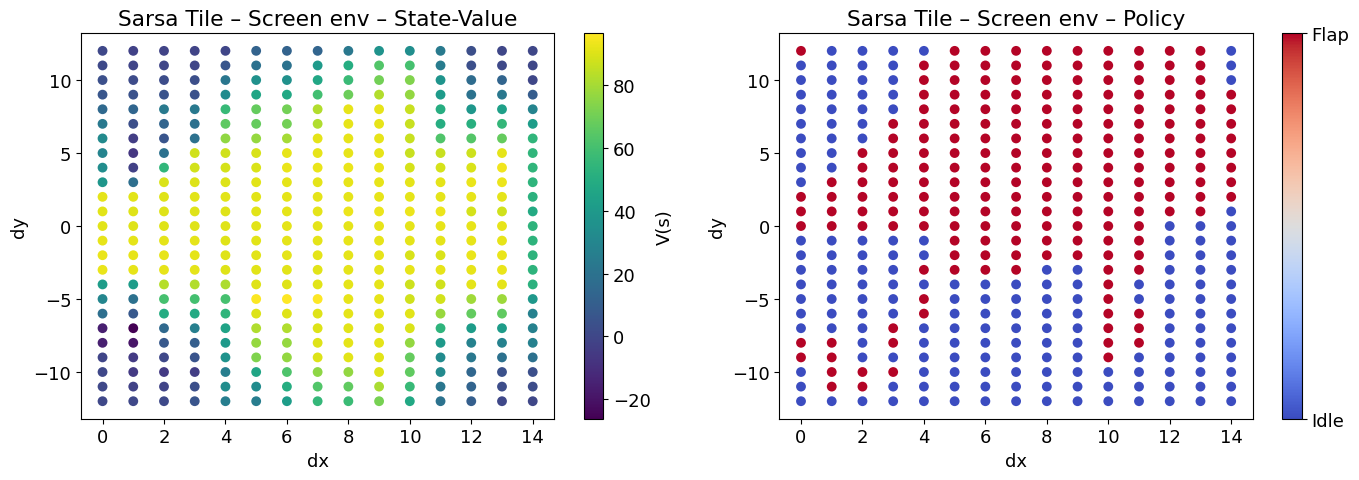

In [40]:
plot_q_tile(w_sarsa_tile, tile_coder_sarsa, title="Sarsa Tile – Screen env")

## 5. Comparison

### 5.1 Training curves: MC Control vs Sarsa($\lambda$)

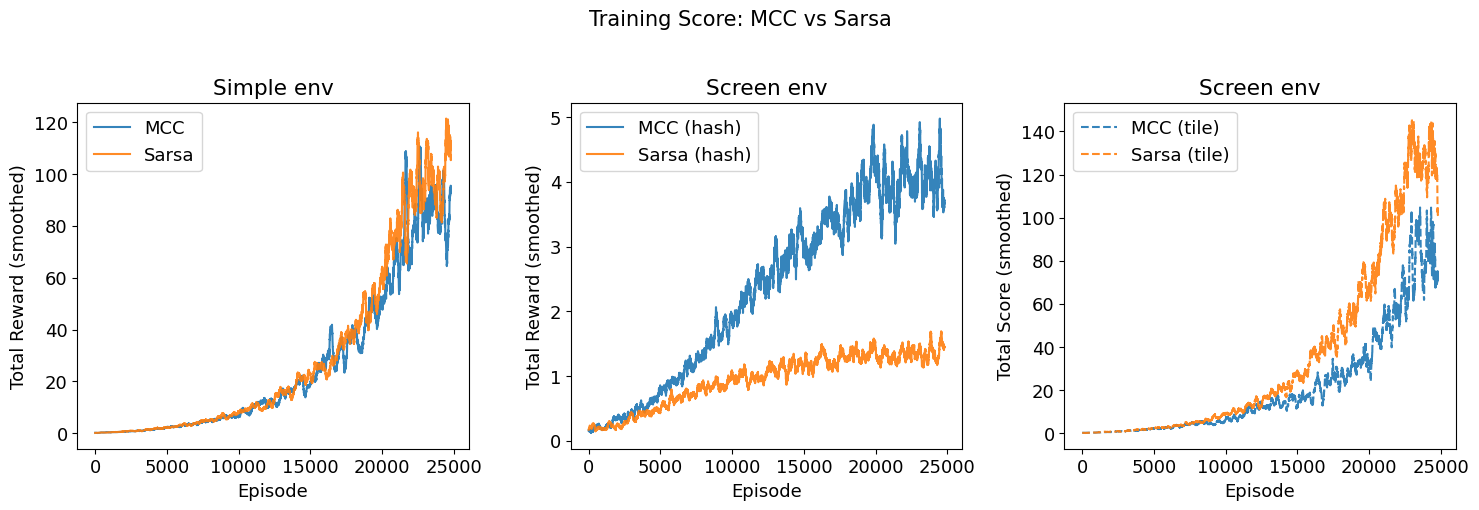

In [41]:
def smooth(arr, window=200):
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode="valid")


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Simple env
axes[0].plot(smooth(stats_mc["scores"]), label="MCC", alpha=0.9)
axes[0].plot(smooth(stats_sarsa["scores"]), label="Sarsa", alpha=0.9)
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total Reward (smoothed)")
axes[0].set_title("Simple env")
axes[0].legend()

# Screen env
axes[1].plot(smooth(stats_mc_scr["scores"]), label="MCC (hash)", alpha=0.9)
axes[1].plot(smooth(stats_sarsa_scr["scores"]), label="Sarsa (hash)", alpha=0.9)

axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Total Reward (smoothed)")
axes[1].set_title("Screen env")
axes[1].legend()

axes[2].plot(
    smooth(stats_mc_tile["scores"]), label="MCC (tile)", alpha=0.9, linestyle="--"
)
axes[2].plot(
    smooth(stats_sarsa_tile["scores"]), label="Sarsa (tile)", alpha=0.9, linestyle="--"
)
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Total Score (smoothed)")
axes[2].set_title("Screen env")
axes[2].legend()

plt.suptitle("Training Score: MCC vs Sarsa", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Evaluation summary (greedy policy)

In [42]:
results = {
    ("MCC", "v0"): (rewards_eval, scores_eval),
    ("Sarsa", "v0"): (rewards_eval_s, scores_eval_s),
    ("MCC", "screen-v0"): (rewards_eval_scr, scores_eval_scr),
    ("Sarsa", "screen-v0"): (rewards_eval_ss, scores_eval_ss),
    ("MCC Tile", "screen-v0"): (rewards_eval_mc_tile, scores_eval_mc_tile),
    ("Sarsa Tile", "screen-v0"): (rewards_eval_sarsa_tile, scores_eval_sarsa_tile),
}

print(
    f"{'Agent':<15} {'Env':<12} {'Mean Reward':>12} {'Std Reward':>12} {'Mean Score':>12} {'Std Score':>12} {'Median Reward':>15} {'Median Score':>15}"
)
print("-" * 115)
for (agent_name, env_name), (rews, scrs) in results.items():
    print(
        f"{agent_name:<15} {env_name:<12} {np.mean(rews):>12.1f} {np.std(rews):>12.1f} {np.mean(scrs):>12.2f} {np.std(scrs):>12.2f} {np.median(rews):>15.1f} {np.median(scrs):>15.2f}"
    )

Agent           Env           Mean Reward   Std Reward   Mean Score    Std Score   Median Reward    Median Score
-------------------------------------------------------------------------------------------------------------------
MCC             v0                50000.0          0.0      4999.00         0.00         50000.0         4999.00
Sarsa           v0                50000.0          0.0      4999.00         0.00         50000.0         4999.00
MCC             screen-v0            58.6         52.2         4.59         5.21            41.5            3.00
Sarsa           screen-v0            25.9         16.8         1.40         1.68            23.0            1.00
MCC Tile        screen-v0         50000.0          0.0      4999.00         0.00         50000.0         4999.00
Sarsa Tile      screen-v0         50000.0          0.0      4999.00         0.00         50000.0         4999.00


### 5.3 Value Function Comparison

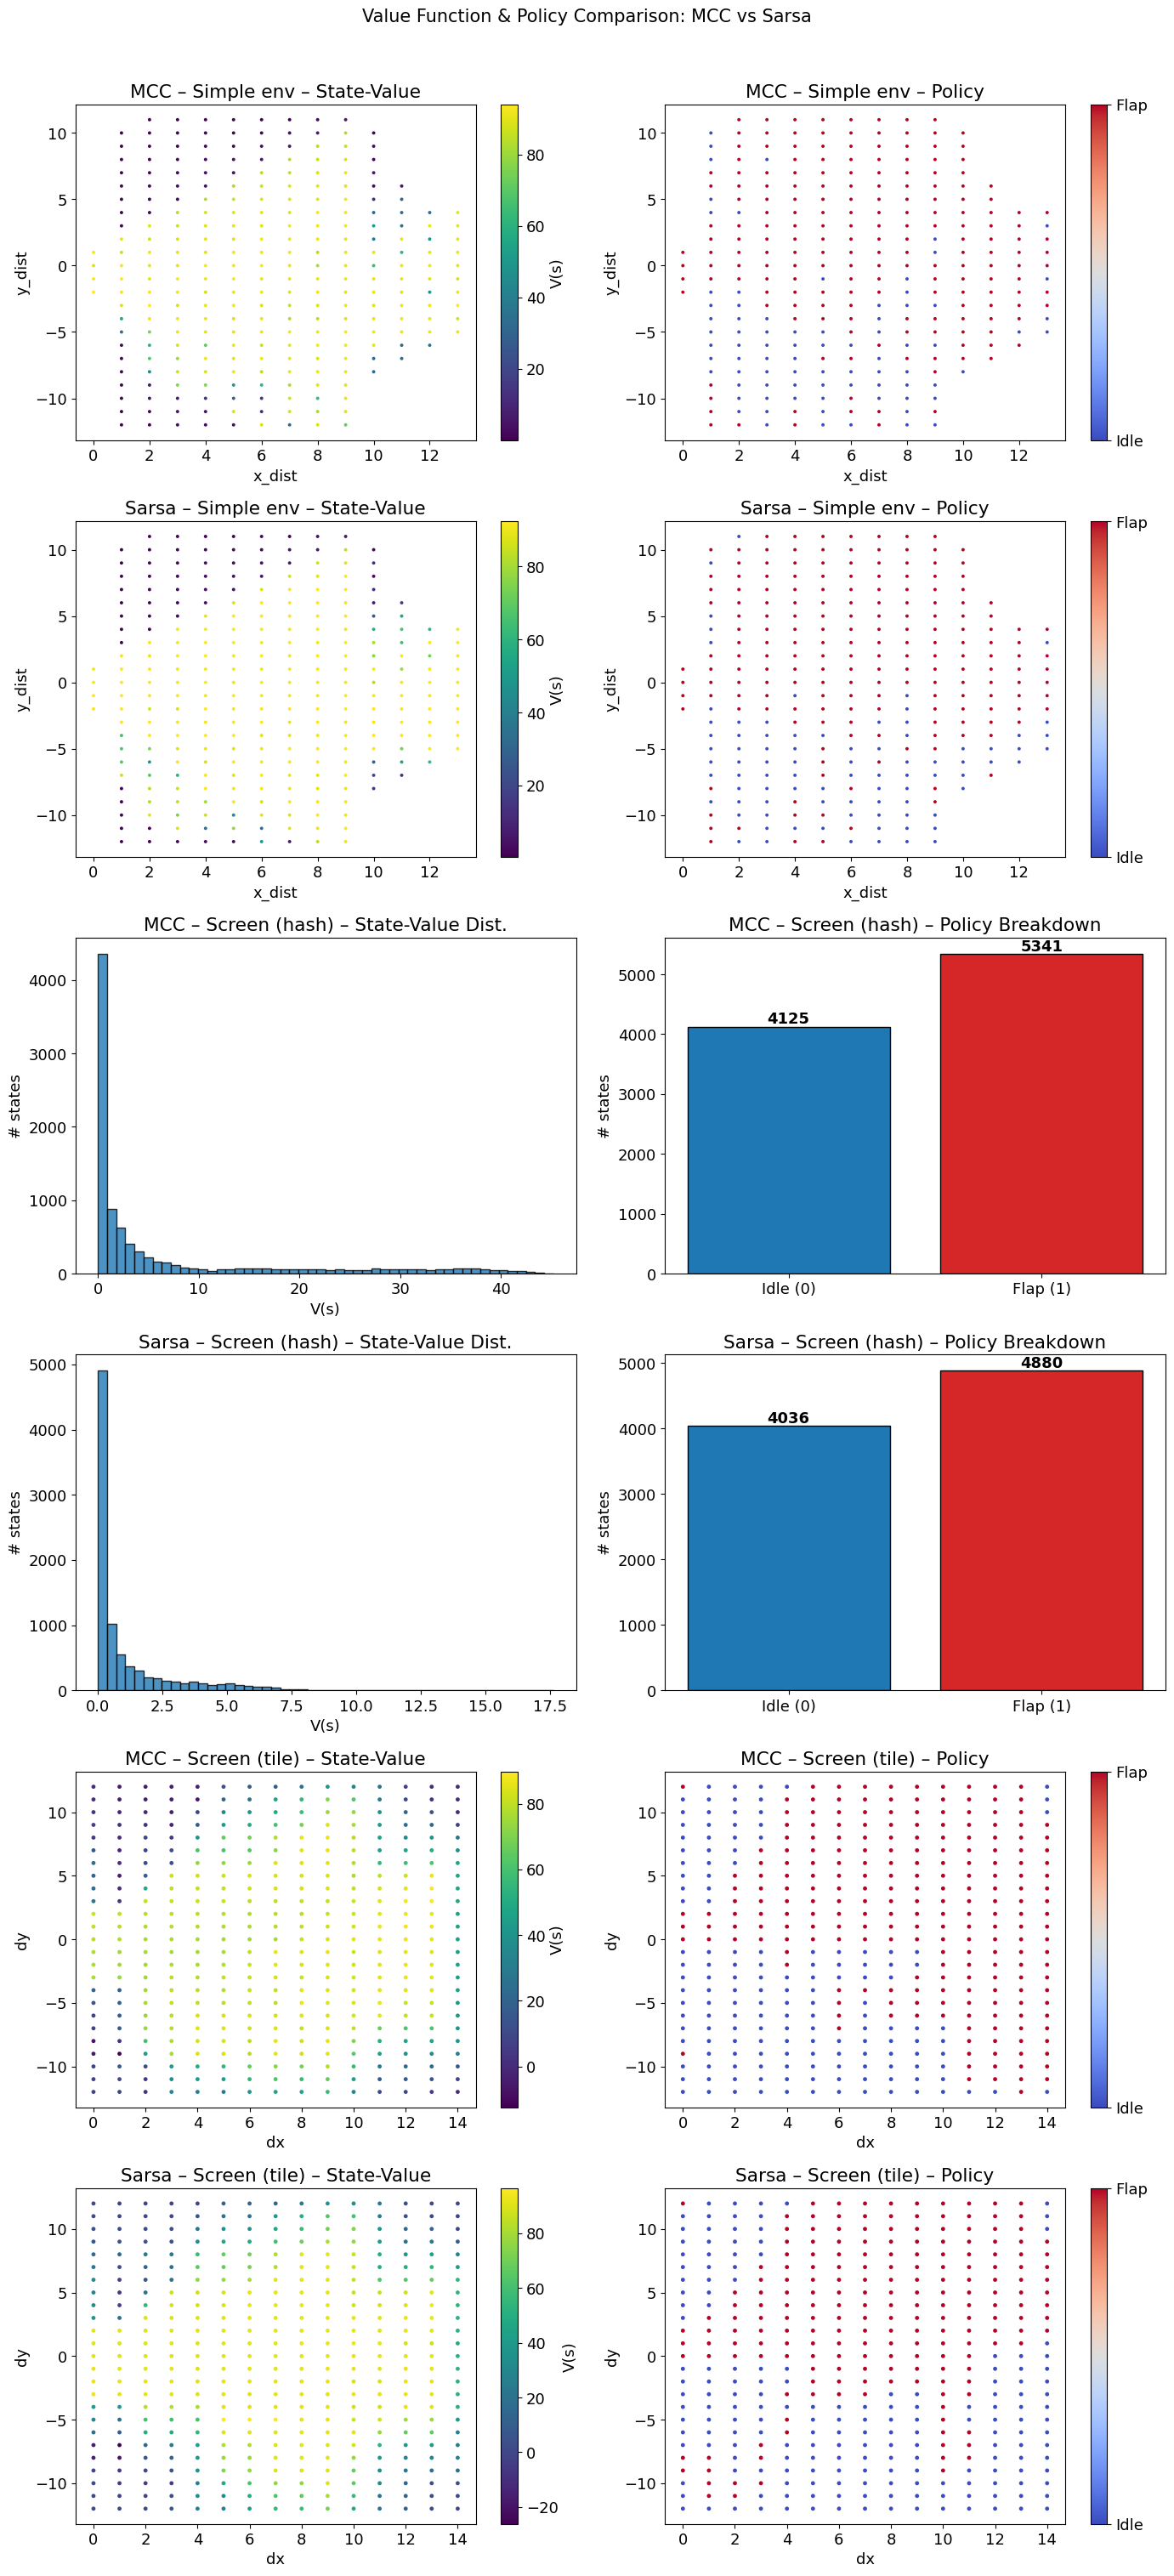

In [43]:
fig, axes = plt.subplots(6, 2, figsize=(14, 30))

# --- Row 0: MCC – Simple env ---
states_mc = [s for s in Q_mc if isinstance(s, tuple) and len(s) == 2]
x_mc = [s[0] for s in states_mc]
y_mc = [s[1] for s in states_mc]
v_mc = [Q_mc[s].max() for s in states_mc]
pol_mc = [Q_mc[s].argmax() for s in states_mc]

sc = axes[0, 0].scatter(x_mc, y_mc, c=v_mc, cmap="viridis", s=8, edgecolors="none")
axes[0, 0].set_xlabel("x_dist")
axes[0, 0].set_ylabel("y_dist")
axes[0, 0].set_title("MCC – Simple env – State-Value")
fig.colorbar(sc, ax=axes[0, 0], label="V(s)")

sc = axes[0, 1].scatter(
    x_mc, y_mc, c=pol_mc, cmap="coolwarm", s=8, edgecolors="none", vmin=0, vmax=1
)
axes[0, 1].set_xlabel("x_dist")
axes[0, 1].set_ylabel("y_dist")
axes[0, 1].set_title("MCC – Simple env – Policy")
cbar = fig.colorbar(sc, ax=axes[0, 1], ticks=[0, 1])
cbar.ax.set_yticklabels(["Idle", "Flap"])

# --- Row 1: Sarsa – Simple env ---
states_sa = [s for s in Q_sarsa if isinstance(s, tuple) and len(s) == 2]
x_sa = [s[0] for s in states_sa]
y_sa = [s[1] for s in states_sa]
v_sa = [Q_sarsa[s].max() for s in states_sa]
pol_sa = [Q_sarsa[s].argmax() for s in states_sa]

sc = axes[1, 0].scatter(x_sa, y_sa, c=v_sa, cmap="viridis", s=8, edgecolors="none")
axes[1, 0].set_xlabel("x_dist")
axes[1, 0].set_ylabel("y_dist")
axes[1, 0].set_title("Sarsa – Simple env – State-Value")
fig.colorbar(sc, ax=axes[1, 0], label="V(s)")

sc = axes[1, 1].scatter(
    x_sa, y_sa, c=pol_sa, cmap="coolwarm", s=8, edgecolors="none", vmin=0, vmax=1
)
axes[1, 1].set_xlabel("x_dist")
axes[1, 1].set_ylabel("y_dist")
axes[1, 1].set_title("Sarsa – Simple env – Policy")
cbar = fig.colorbar(sc, ax=axes[1, 1], ticks=[0, 1])
cbar.ax.set_yticklabels(["Idle", "Flap"])

# --- Row 2: MCC – Screen (hash) ---
v_mc_scr = [Q_mc_scr[s].max() for s in Q_mc_scr]
a_mc_scr = [Q_mc_scr[s].argmax() for s in Q_mc_scr]

axes[2, 0].hist(v_mc_scr, bins=50, edgecolor="black", alpha=0.8)
axes[2, 0].set_xlabel("V(s)")
axes[2, 0].set_ylabel("# states")
axes[2, 0].set_title("MCC – Screen (hash) – State-Value Dist.")

n_idle = sum(1 for a in a_mc_scr if a == 0)
n_flap = sum(1 for a in a_mc_scr if a == 1)
bars = axes[2, 1].bar(
    ["Idle (0)", "Flap (1)"],
    [n_idle, n_flap],
    color=["tab:blue", "tab:red"],
    edgecolor="black",
)
for bar, val in zip(bars, [n_idle, n_flap]):
    axes[2, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(val),
        ha="center",
        va="bottom",
        fontweight="bold",
    )
axes[2, 1].set_ylabel("# states")
axes[2, 1].set_title("MCC – Screen (hash) – Policy Breakdown")

# --- Row 3: Sarsa – Screen (hash) ---
v_sa_scr = [Q_sarsa_scr[s].max() for s in Q_sarsa_scr]
a_sa_scr = [Q_sarsa_scr[s].argmax() for s in Q_sarsa_scr]

axes[3, 0].hist(v_sa_scr, bins=50, edgecolor="black", alpha=0.8)
axes[3, 0].set_xlabel("V(s)")
axes[3, 0].set_ylabel("# states")
axes[3, 0].set_title("Sarsa – Screen (hash) – State-Value Dist.")

n_idle = sum(1 for a in a_sa_scr if a == 0)
n_flap = sum(1 for a in a_sa_scr if a == 1)
bars = axes[3, 1].bar(
    ["Idle (0)", "Flap (1)"],
    [n_idle, n_flap],
    color=["tab:blue", "tab:red"],
    edgecolor="black",
)
for bar, val in zip(bars, [n_idle, n_flap]):
    axes[3, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(val),
        ha="center",
        va="bottom",
        fontweight="bold",
    )
axes[3, 1].set_ylabel("# states")
axes[3, 1].set_title("Sarsa – Screen (hash) – Policy Breakdown")

# --- Row 4: MCC – Screen (tile) ---
dx_vals = np.arange(0, 15)
dy_vals = np.arange(-12, 13)
xs = np.repeat(dx_vals, len(dy_vals))
ys = np.tile(dy_vals, len(dx_vals))

V_mc_tile = np.array(
    [
        tile_get_q(w_mc_tile, tile_coder_mc, (dx, dy)).max()
        for dx in dx_vals
        for dy in dy_vals
    ]
)
P_mc_tile = np.array(
    [
        tile_get_q(w_mc_tile, tile_coder_mc, (dx, dy)).argmax()
        for dx in dx_vals
        for dy in dy_vals
    ]
)

sc = axes[4, 0].scatter(xs, ys, c=V_mc_tile, cmap="viridis", s=12, edgecolors="none")
axes[4, 0].set_xlabel("dx")
axes[4, 0].set_ylabel("dy")
axes[4, 0].set_title("MCC – Screen (tile) – State-Value")
fig.colorbar(sc, ax=axes[4, 0], label="V(s)")

sc = axes[4, 1].scatter(
    xs, ys, c=P_mc_tile, cmap="coolwarm", s=12, edgecolors="none", vmin=0, vmax=1
)
axes[4, 1].set_xlabel("dx")
axes[4, 1].set_ylabel("dy")
axes[4, 1].set_title("MCC – Screen (tile) – Policy")
cbar = fig.colorbar(sc, ax=axes[4, 1], ticks=[0, 1])
cbar.ax.set_yticklabels(["Idle", "Flap"])

# --- Row 5: Sarsa – Screen (tile) ---
V_sa_tile = np.array(
    [
        tile_get_q(w_sarsa_tile, tile_coder_sarsa, (dx, dy)).max()
        for dx in dx_vals
        for dy in dy_vals
    ]
)
P_sa_tile = np.array(
    [
        tile_get_q(w_sarsa_tile, tile_coder_sarsa, (dx, dy)).argmax()
        for dx in dx_vals
        for dy in dy_vals
    ]
)

sc = axes[5, 0].scatter(xs, ys, c=V_sa_tile, cmap="viridis", s=12, edgecolors="none")
axes[5, 0].set_xlabel("dx")
axes[5, 0].set_ylabel("dy")
axes[5, 0].set_title("Sarsa – Screen (tile) – State-Value")
fig.colorbar(sc, ax=axes[5, 0], label="V(s)")

sc = axes[5, 1].scatter(
    xs, ys, c=P_sa_tile, cmap="coolwarm", s=12, edgecolors="none", vmin=0, vmax=1
)
axes[5, 1].set_xlabel("dx")
axes[5, 1].set_ylabel("dy")
axes[5, 1].set_title("Sarsa – Screen (tile) – Policy")
cbar = fig.colorbar(sc, ax=axes[5, 1], ticks=[0, 1])
cbar.ax.set_yticklabels(["Idle", "Flap"])

plt.suptitle("Value Function & Policy Comparison: MCC vs Sarsa", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 5.4 Visual demo of the trained agents (simple env)

In [42]:
def demo_agent(Q, env_name="TextFlappyBird-v0", max_steps=1000, delay=0.02):
    """Run a visual demo of the greedy policy derived from Q."""
    env = gym.make(env_name, height=15, width=20, pipe_gap=4)
    obs, info = env.reset()
    for step in range(max_steps):
        q_vals = Q[obs]
        action = np.random.choice(np.flatnonzero(q_vals == q_vals.max()))
        obs, reward, done, _, info = env.step(action)
        clear_output(wait=True)
        print(env.render())
        time.sleep(delay)
        if done:
            break
    print(f"Final score: {info['score']}  |  Steps survived: {step + 1}")
    env.close()


In [43]:
# Demo MC Control agent
print("=== MC Control agent ===")
demo_agent(Q_mc, "TextFlappyBird-v0")

Text Flappy Bird!
Score: 99
----------------------
[         |          ]
[                    ]
[                    ]
[                    ]
[                    ]
[      @  |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
^^^^^^^^^^^^^^^^^^^^^^
Player Action (Flap)
Distance From Pipe (dx=3,dy=2)

Final score: 99  |  Steps survived: 1000


In [44]:
# Demo Sarsa agent
print("=== Sarsa agent ===")
demo_agent(Q_sarsa, "TextFlappyBird-v0")

Text Flappy Bird!
Score: 99
----------------------
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[      @             ]
[                    ]
[                    ]
[                    ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
^^^^^^^^^^^^^^^^^^^^^^
Player Action (Idle)
Distance From Pipe (dx=3,dy=-2)

Final score: 99  |  Steps survived: 1000


## 6. Sensitivity to Hyperparameters

For each agent we sweep one hyperparameter at a time (keeping the others at their baseline values), train on **both** environments, and evaluate with a greedy policy.  
Each configuration is trained once and evaluated over 200 episodes. The plots show the median reward and score across evaluation episodes.

In [30]:
SENSITIVITY_EPISODES = 5000  # shorter training for sweeps
EVAL_EPISODES = 20

# Baseline hyperparameters (shared by MC and Sarsa where applicable)
BASELINE = dict(alpha=0.01, gamma=0.99, eps_decay=0.9998, eps_min=0.01, eps_start=1.0)
BASELINE_LAM = 0.8  # only for Sarsa
BASELINE_TILE = dict(
    num_tilings=8, tiles_per_dim=4, feature_ranges=((0, 14), (-12, 12))
)


def sensitivity_sweep_mc(param_name, param_values):
    results = {v: {} for v in param_values}
    for val in param_values:
        kwargs = {**BASELINE, "num_episodes": SENSITIVITY_EPISODES}
        kwargs[param_name] = val

        env = gym.make("TextFlappyBird-v0", height=15, width=20, pipe_gap=4)
        Q, _ = mc_control(env, **kwargs)
        env.close()
        _, scrs = evaluate_policy(Q, "TextFlappyBird-v0", n_episodes=EVAL_EPISODES)
        results[val]["v0"] = np.median(scrs)

        tc = TileCoding(**BASELINE_TILE)
        env = gym.make("TextFlappyBird-screen-v0", height=15, width=20, pipe_gap=4)
        w, _ = mc_control_screen_tile(env, tc, **kwargs)
        env.close()
        _, scrs = evaluate_policy_screen_tile(
            w, tc, "TextFlappyBird-screen-v0", n_episodes=EVAL_EPISODES
        )
        results[val]["screen"] = np.median(scrs)

    return results


def sensitivity_sweep_sarsa(param_name, param_values):
    results = {v: {} for v in param_values}
    for val in param_values:
        kwargs = {**BASELINE, "lam": BASELINE_LAM, "num_episodes": SENSITIVITY_EPISODES}
        kwargs[param_name] = val

        env = gym.make("TextFlappyBird-v0", height=15, width=20, pipe_gap=4)
        Q, _ = sarsa_lambda(env, **kwargs)
        env.close()
        _, scrs = evaluate_policy(Q, "TextFlappyBird-v0", n_episodes=EVAL_EPISODES)
        results[val]["v0"] = np.median(scrs)

        tc = TileCoding(**BASELINE_TILE)
        env = gym.make("TextFlappyBird-screen-v0", height=15, width=20, pipe_gap=4)
        w, _ = sarsa_lambda_screen_tile(env, tc, **kwargs)
        env.close()
        _, scrs = evaluate_policy_screen_tile(
            w, tc, "TextFlappyBird-screen-v0", n_episodes=EVAL_EPISODES
        )
        results[val]["screen"] = np.median(scrs)

    return results


def plot_sensitivity(results, param_name, agent_label):
    """1x2: left = Simple env, right = Screen env (tile). Median score only."""
    vals = sorted(results.keys())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for col, (env_key, env_label) in enumerate(
        [
            ("v0", "Simple env"),
            ("screen", "Screen env (tile)"),
        ]
    ):
        med_s = [results[v][env_key] for v in vals]
        ax = axes[col]
        ax.plot(vals, med_s, "-o")
        ax.set_xlabel(param_name)
        ax.set_ylabel("Median Score")
        ax.set_title(f"{agent_label} – {env_label}")

    plt.tight_layout()
    plt.show()

### 6.1 MCC - Parameter Sensitivity

Evaluating policy: 100%|██████████| 20/20 [00:01<00:00, 17.28it/s]


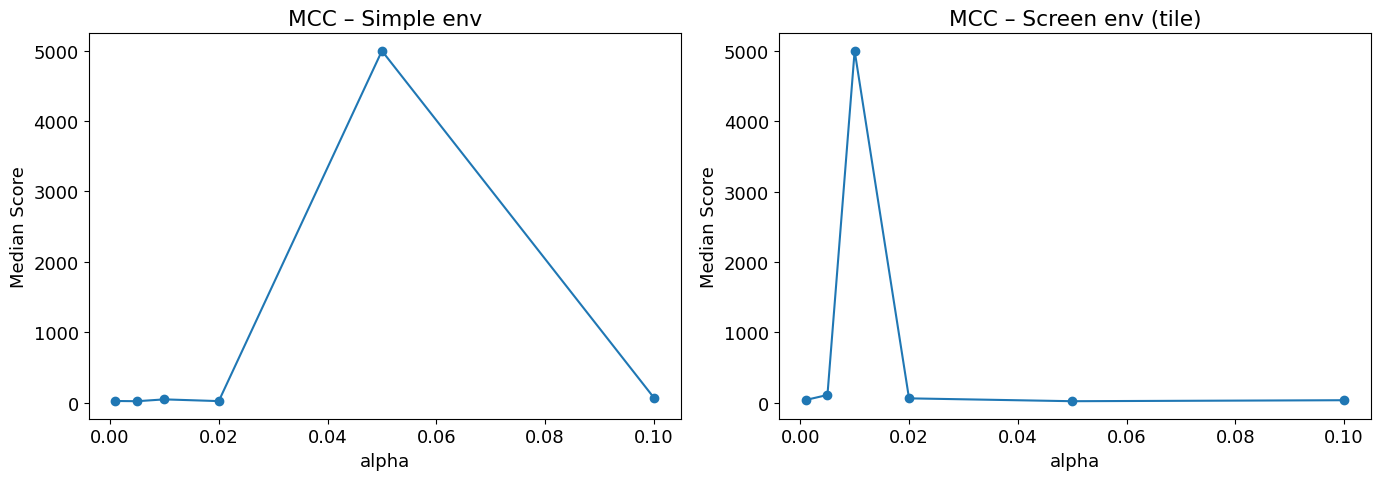

In [31]:
# MC: alpha sweep
alpha_values = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
mc_alpha_results = sensitivity_sweep_mc("alpha", alpha_values)
plot_sensitivity(mc_alpha_results, "alpha", "MCC")

Evaluating policy: 100%|██████████| 20/20 [00:01<00:00, 15.55it/s]


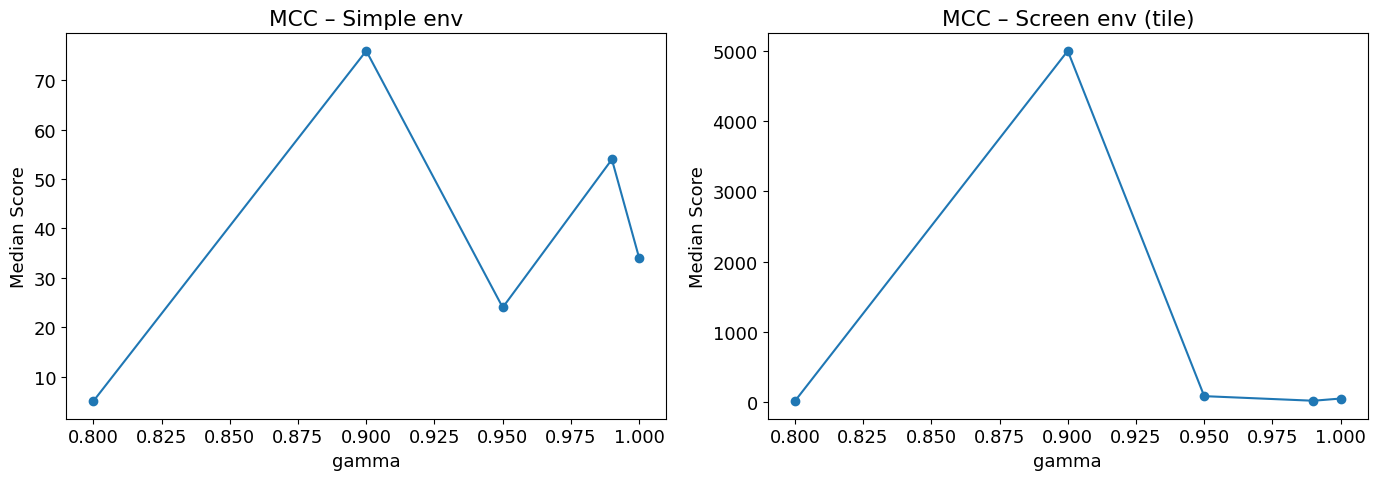

In [32]:
# MC: gamma sweep
gamma_values = [0.8, 0.9, 0.95, 0.99, 1.0]
mc_gamma_results = sensitivity_sweep_mc("gamma", gamma_values)
plot_sensitivity(mc_gamma_results, "gamma", "MCC")

Evaluating policy: 100%|██████████| 20/20 [00:01<00:00, 18.98it/s]


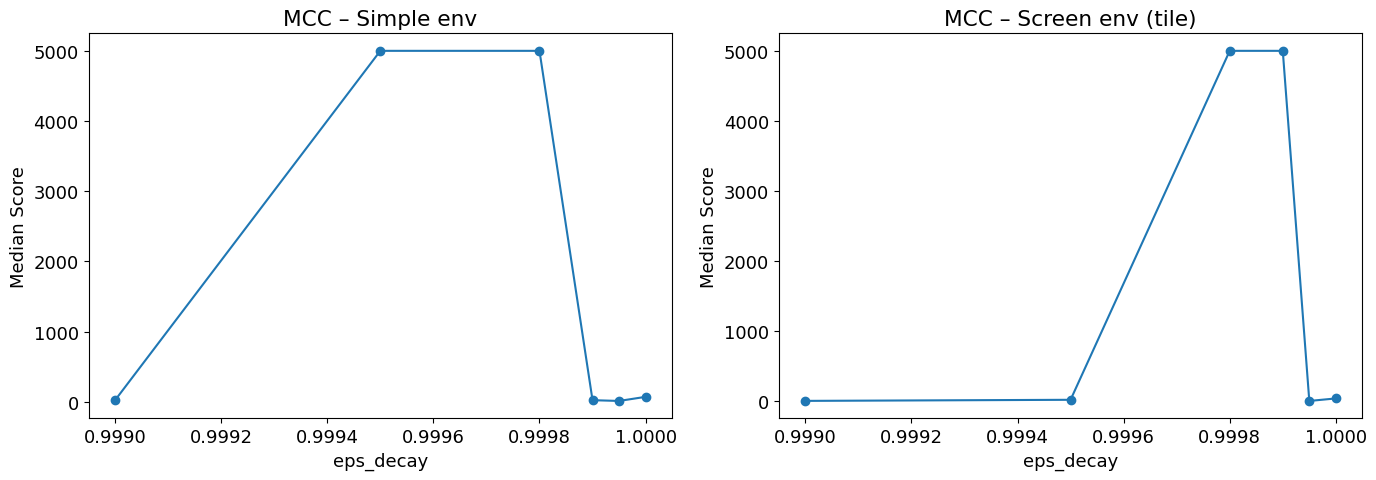

In [33]:
# MC: eps_decay sweep
eps_decay_values = [0.999, 0.9995, 0.9998, 0.9999, 0.99995, 1.0]
mc_eps_results = sensitivity_sweep_mc("eps_decay", eps_decay_values)
plot_sensitivity(mc_eps_results, "eps_decay", "MCC")

### 6.2 Sarsa($\lambda$) – Parameter Sensitivity

Evaluating policy: 100%|██████████| 20/20 [00:00<00:00, 103.76it/s]


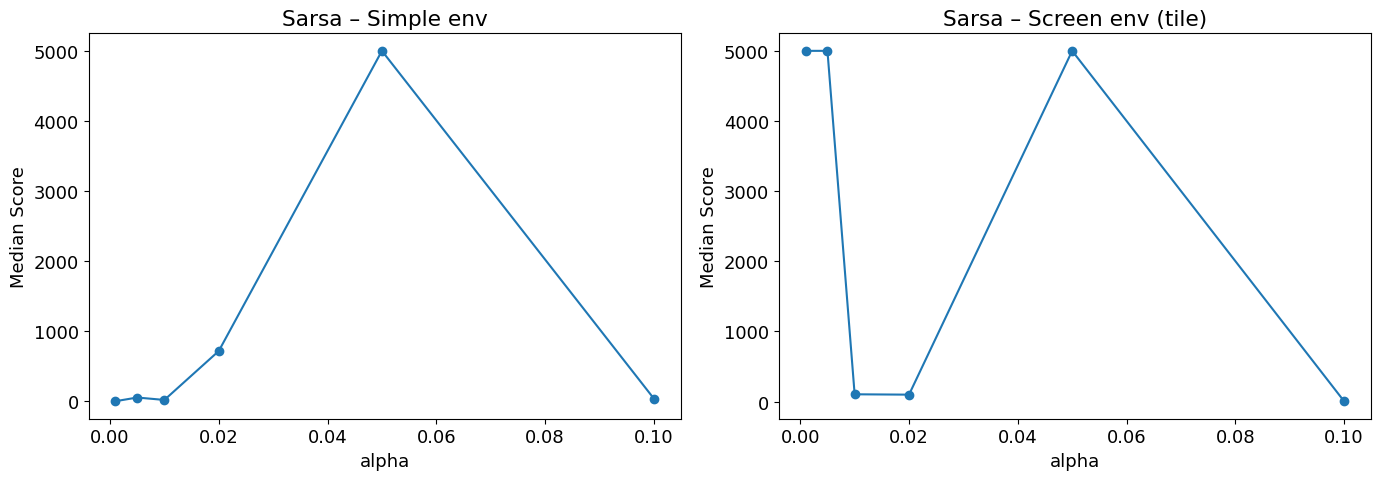

In [34]:
# Sarsa: alpha sweep
alpha_values = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
sarsa_alpha_results = sensitivity_sweep_sarsa("alpha", alpha_values)
plot_sensitivity(sarsa_alpha_results, "alpha", "Sarsa")

Evaluating policy: 100%|██████████| 20/20 [01:44<00:00,  5.24s/it]


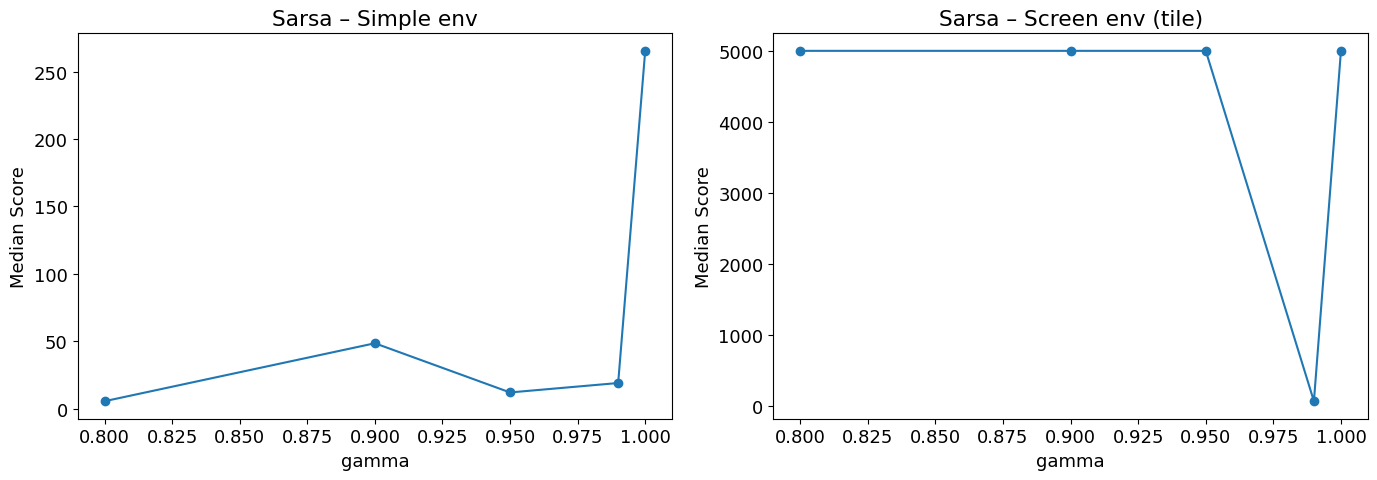

In [35]:
# Sarsa: gamma sweep
gamma_values = [0.8, 0.9, 0.95, 0.99, 1.0]
sarsa_gamma_results = sensitivity_sweep_sarsa("gamma", gamma_values)
plot_sensitivity(sarsa_gamma_results, "gamma", "Sarsa")

Evaluating policy: 100%|██████████| 20/20 [00:01<00:00, 13.17it/s]


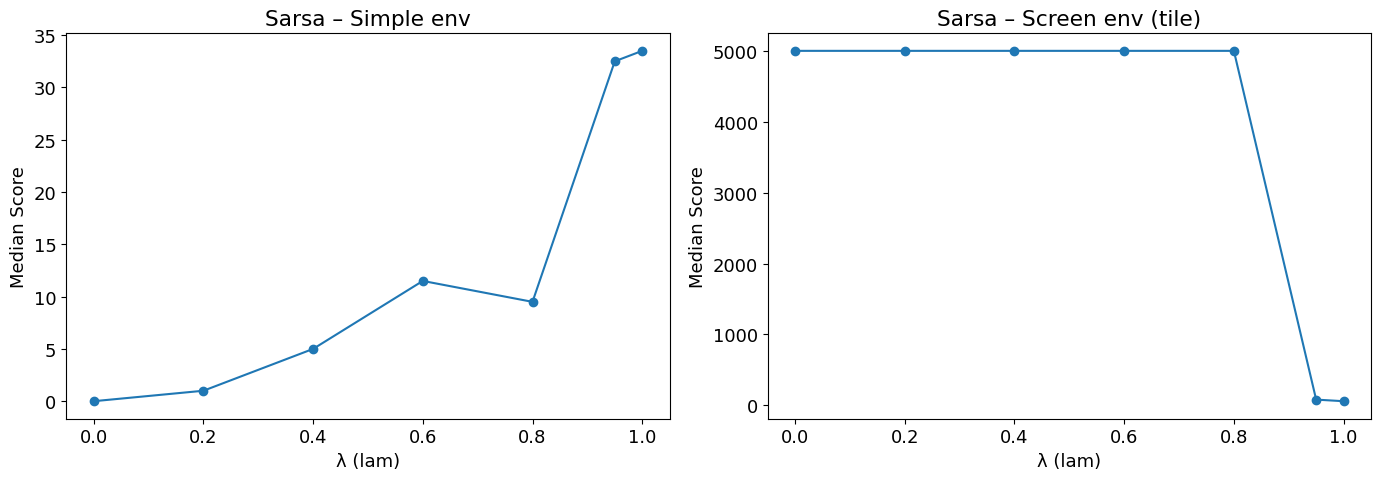

In [36]:
# Sarsa: lambda sweep
lam_values = [0.0, 0.2, 0.4, 0.6, 0.8, 0.95, 1.0]
sarsa_lam_results = sensitivity_sweep_sarsa("lam", lam_values)
plot_sensitivity(sarsa_lam_results, "λ (lam)", "Sarsa")

Evaluating policy: 100%|██████████| 20/20 [01:45<00:00,  5.29s/it]


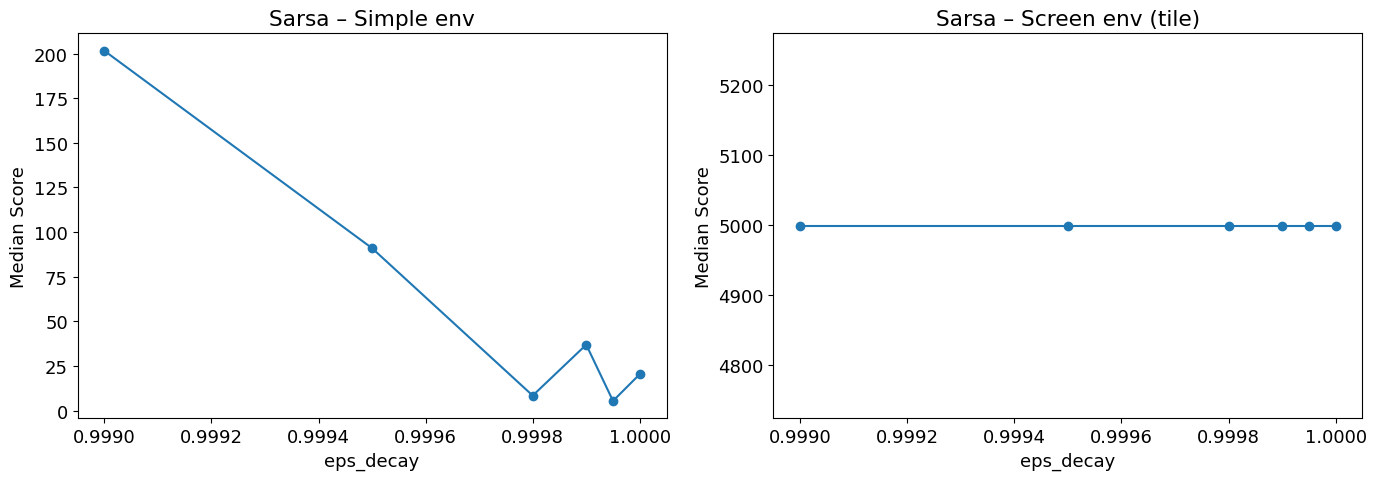

In [37]:
# Sarsa: eps_decay sweep
eps_decay_values = [0.999, 0.9995, 0.9998, 0.9999, 0.99995, 1.0]
sarsa_eps_results = sensitivity_sweep_sarsa("eps_decay", eps_decay_values)
plot_sensitivity(sarsa_eps_results, "eps_decay", "Sarsa")

## 7. Generalization to Different Environment Configurations

Agents are trained **once** on the base configuration (`height=15, width=20, pipe_gap=4`) and then evaluated on environments with **different configurations** (varying pipe gap, height, and width). This tests how well the learned policies transfer to unseen settings.

In [19]:
def evaluate_policy_custom(Q, env_name, n_episodes=200, max_steps=50000, **env_kwargs):
    """Evaluate greedy policy on an env created with arbitrary kwargs."""
    env = gym.make(env_name, **env_kwargs)
    rewards_list, scores_list = [], []
    for _ in tqdm(range(n_episodes), desc="Evaluating"):
        obs, info = env.reset()
        total_reward = 0
        for _ in range(max_steps):
            q_vals = Q.get(obs, np.zeros(env.action_space.n))
            action = np.random.choice(np.flatnonzero(q_vals == q_vals.max()))
            obs, reward, done, _, info = env.step(action)
            total_reward += reward
            if done:
                break
        rewards_list.append(total_reward)
        scores_list.append(info["score"])
    env.close()
    return rewards_list, scores_list


def evaluate_policy_screen_custom(
    Q, env_name, n_episodes=200, max_steps=50000, **env_kwargs
):
    """Evaluate greedy policy for screen-based env (uses hashable_obs)."""
    env = gym.make(env_name, **env_kwargs)
    rewards_list, scores_list = [], []
    for _ in tqdm(range(n_episodes), desc="Evaluating"):
        obs, info = env.reset()
        state = hashable_obs(obs)
        total_reward = 0
        for _ in range(max_steps):
            q_vals = Q.get(state, np.zeros(env.action_space.n))
            action = np.random.choice(np.flatnonzero(q_vals == q_vals.max()))
            obs, reward, done, _, info = env.step(action)
            state = hashable_obs(obs)
            total_reward += reward
            if done:
                break
        rewards_list.append(total_reward)
        scores_list.append(info["score"])
    env.close()
    return rewards_list, scores_list


def evaluate_policy_screen_tile_custom(
    w, tile_coder, env_name, n_episodes=200, max_steps=50000, **env_kwargs
):
    """Evaluate greedy tile-coded policy for screen-based env with arbitrary kwargs."""
    env = gym.make(env_name, **env_kwargs)
    n_actions = env.action_space.n
    rewards_list, scores_list = [], []
    for _ in tqdm(range(n_episodes), desc="Evaluating"):
        obs, info = env.reset()
        features = extract_features_from_screen(obs)
        total_reward = 0
        for _ in range(max_steps):
            q = tile_get_q(w, tile_coder, features, n_actions)
            action = np.random.choice(np.flatnonzero(q == q.max()))
            obs, reward, done, _, info = env.step(action)
            features = extract_features_from_screen(obs)
            total_reward += reward
            if done:
                break
        rewards_list.append(total_reward)
        scores_list.append(info["score"])
    env.close()
    return rewards_list, scores_list

In [20]:
# Environment configurations to test (trained on the first one)
TEST_CONFIGS = [
    {"height": 15, "width": 20, "pipe_gap": 3},  # harder (narrower gap)
    {"height": 15, "width": 20, "pipe_gap": 5},  # easier (wider gap)
    {"height": 15, "width": 20, "pipe_gap": 6},  # much easier
    {"height": 12, "width": 20, "pipe_gap": 4},  # shorter screen
    {"height": 18, "width": 20, "pipe_gap": 4},  # taller screen
    {"height": 15, "width": 15, "pipe_gap": 4},  # narrower screen
    {"height": 15, "width": 25, "pipe_gap": 4},  # wider screen
]

GENERALIZATION_EVAL_EPISODES = 20

env_mc = gym.make("TextFlappyBird-v0", height=15, width=20, pipe_gap=4)

Q_mc, stats_mc = mc_control(
    env_mc,
    num_episodes=25000,
    alpha=0.01,
    gamma=0.99,
    eps_start=1.0,
    eps_decay=0.9998,
    eps_min=0.01,
)
env_mc.close()

env_mc_scr = gym.make("TextFlappyBird-screen-v0", height=15, width=20, pipe_gap=4)

Q_mc_scr, stats_mc_scr = mc_control_screen(
    env_mc_scr,
    num_episodes=25000,
    alpha=0.01,
    gamma=0.99,
    eps_start=1.0,
    eps_decay=0.9998,
    eps_min=0.01,
)
env_mc_scr.close()

tile_coder_mc = TileCoding(
    num_tilings=8, tiles_per_dim=4, feature_ranges=((0, 14), (-12, 12))
)
env_mc_tile = gym.make("TextFlappyBird-screen-v0", height=15, width=20, pipe_gap=4)
Q_mc_tile, stats_mc_tile = mc_control_screen_tile(
    env_mc_tile,
    tile_coder_mc,
    num_episodes=25000,
    alpha=0.01,
    gamma=0.99,
    eps_start=1.0,
    eps_decay=0.9998,
    eps_min=0.01,
)
env_mc_tile.close()

# Agents: (label, Q_or_w, tile_coder_or_None, env_name, obs_type)
agents = [
    ("MCC simple", Q_mc, None, "TextFlappyBird-v0", "simple"),
    ("MCC screen", Q_mc_scr, None, "TextFlappyBird-screen-v0", "screen"),
    ("MCC tile", Q_mc_tile, tile_coder_mc, "TextFlappyBird-screen-v0", "tile"),
]

# Run evaluations
generalization_results = {}  # (agent_label, config_str) -> median_score
for agent_label, q_or_w, tc, env_name, obs_type in agents:
    for cfg in TEST_CONFIGS:
        cfg_str = f"h={cfg['height']} w={cfg['width']} gap={cfg['pipe_gap']}"
        print(f"  Evaluating {agent_label} on {cfg_str} ...")
        if obs_type == "simple":
            _, scores = evaluate_policy_custom(
                q_or_w, env_name, n_episodes=GENERALIZATION_EVAL_EPISODES, **cfg
            )
        elif obs_type == "screen":
            _, scores = evaluate_policy_screen_custom(
                q_or_w, env_name, n_episodes=GENERALIZATION_EVAL_EPISODES, **cfg
            )
        else:
            _, scores = evaluate_policy_screen_tile_custom(
                q_or_w, tc, env_name, n_episodes=GENERALIZATION_EVAL_EPISODES, **cfg
            )
        generalization_results[(agent_label, cfg_str)] = np.median(scores)

MCC Tile: 100%|██████████| 25000/25000 [11:38<00:00, 35.77it/s] 


  Evaluating MCC simple on h=15 w=20 gap=3 ...


Evaluating: 100%|██████████| 20/20 [00:00<00:00, 4121.96it/s]


  Evaluating MCC simple on h=15 w=20 gap=5 ...


Evaluating: 100%|██████████| 20/20 [00:07<00:00,  2.78it/s]


...

Evaluating: 100%|██████████| 20/20 [00:00<00:00, 30.50it/s]


  Evaluating MCC tile on h=15 w=15 gap=4 ...


Evaluating: 100%|██████████| 20/20 [00:00<00:00, 35.25it/s]


  Evaluating MCC tile on h=15 w=25 gap=4 ...


Evaluating: 100%|██████████| 20/20 [00:02<00:00,  7.08it/s]


Config                        MCC simple        MCC screen          MCC tile
----------------------------------------------------------------------------
h=15 w=20 gap=3                      0.0               0.0              21.5
h=15 w=20 gap=5                   4999.0               0.0            4999.0
h=15 w=20 gap=6                   4999.0               0.0            4999.0
h=12 w=20 gap=4                   4999.0               0.0            4999.0
h=18 w=20 gap=4                     28.5               0.0              21.0
h=15 w=15 gap=4                     35.0               0.0              19.0
h=15 w=25 gap=4                     36.0               0.0              67.5


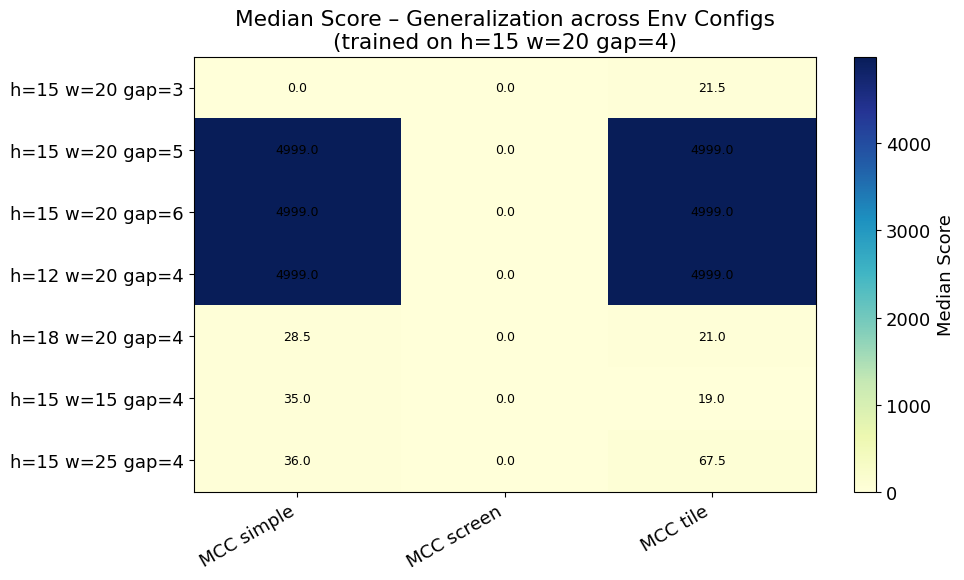

In [22]:
# Build a table: rows = configs, columns = agents
config_labels = [
    f"h={c['height']} w={c['width']} gap={c['pipe_gap']}" for c in TEST_CONFIGS
]
agent_labels = [a[0] for a in agents]

# Print table
header = f"{'Config':<22}" + "".join(f"{a:>18}" for a in agent_labels)
print(header)
print("-" * len(header))
for cfg_str in config_labels:
    row = f"{cfg_str:<22}"
    for agent_label in agent_labels:
        med = generalization_results[(agent_label, cfg_str)]
        row += f"{med:>18.1f}"
    print(row)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
data = np.array(
    [[generalization_results[(a, c)] for a in agent_labels] for c in config_labels]
)
im = ax.imshow(data, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(agent_labels)))
ax.set_xticklabels(agent_labels, rotation=30, ha="right")
ax.set_yticks(range(len(config_labels)))
ax.set_yticklabels(config_labels)
# Annotate cells
for i in range(len(config_labels)):
    for j in range(len(agent_labels)):
        ax.text(j, i, f"{data[i, j]:.1f}", ha="center", va="center", fontsize=9)
ax.set_title(
    "Median Score – Generalization across Env Configs\n(trained on h=15 w=20 gap=4)"
)
fig.colorbar(im, ax=ax, label="Median Score")
plt.tight_layout()
plt.show()